# 📊 Python Class 12 — Matplotlib Visual Masterclass
## A Complete Beginner-to-Advanced Visualization Course

Welcome to the final class of this free Python course.

This class takes Matplotlib from **absolute beginner level to a broad professional toolkit**, while keeping the teaching sequence beginner-friendly.

The learning pattern throughout the notebook is:

> **Understand → Visualize → Predict → Code → Run → Verify → Interpret → Apply**

Every major module contains a **visual mental model, flowchart, or diagram** before the main code. The goal is to help a learner understand what the code is doing rather than memorize functions.

### Course language
**English only. No Roman Urdu is used in this notebook.**

### Learning outcomes

By the end of this class, you will understand and use:

- Matplotlib architecture: Figure, Axes, Axis, Artists
- line, bar, horizontal bar, scatter, histogram, pie, box, violin, stem and area charts
- annotations, text, ticks, limits, legends, grids, markers and line styles
- subplots, shared axes, `GridSpec`, inset axes and secondary axes
- NumPy and Pandas integration
- date and time-series visualization
- heatmaps, `imshow()`, `colorbar()`, colormaps and matrix visualization
- correlation visualization
- uncertainty with `errorbar()`
- confidence-style bands with `fill_between()`
- stacked area charts with `stackplot()`
- logarithmic axes
- professional styling with `plt.style.use()` and `rcParams`
- figure sizing, DPI, layout, saving and export
- 3D visualization with `mplot3d`
- debugging and chart-design principles
- football analytics ⚽
- table tennis analytics 🏓

The sports examples use **synthetic educational data** so the notebook is self-contained and reproducible.

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Matplotlib:", matplotlib.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Matplotlib: 3.10.8
NumPy: 2.3.5
Pandas: 2.2.3


# Module 1 — What Is Matplotlib?

Matplotlib is a Python visualization library. It provides tools for converting numerical, categorical, and time-based data into graphical representations.

A visualization should help a reader answer a question faster than raw numbers alone.

Examples:

- Is a quantity increasing?
- Which category is largest?
- How are values distributed?
- Do two variables appear related?
- How uncertain is an estimate?

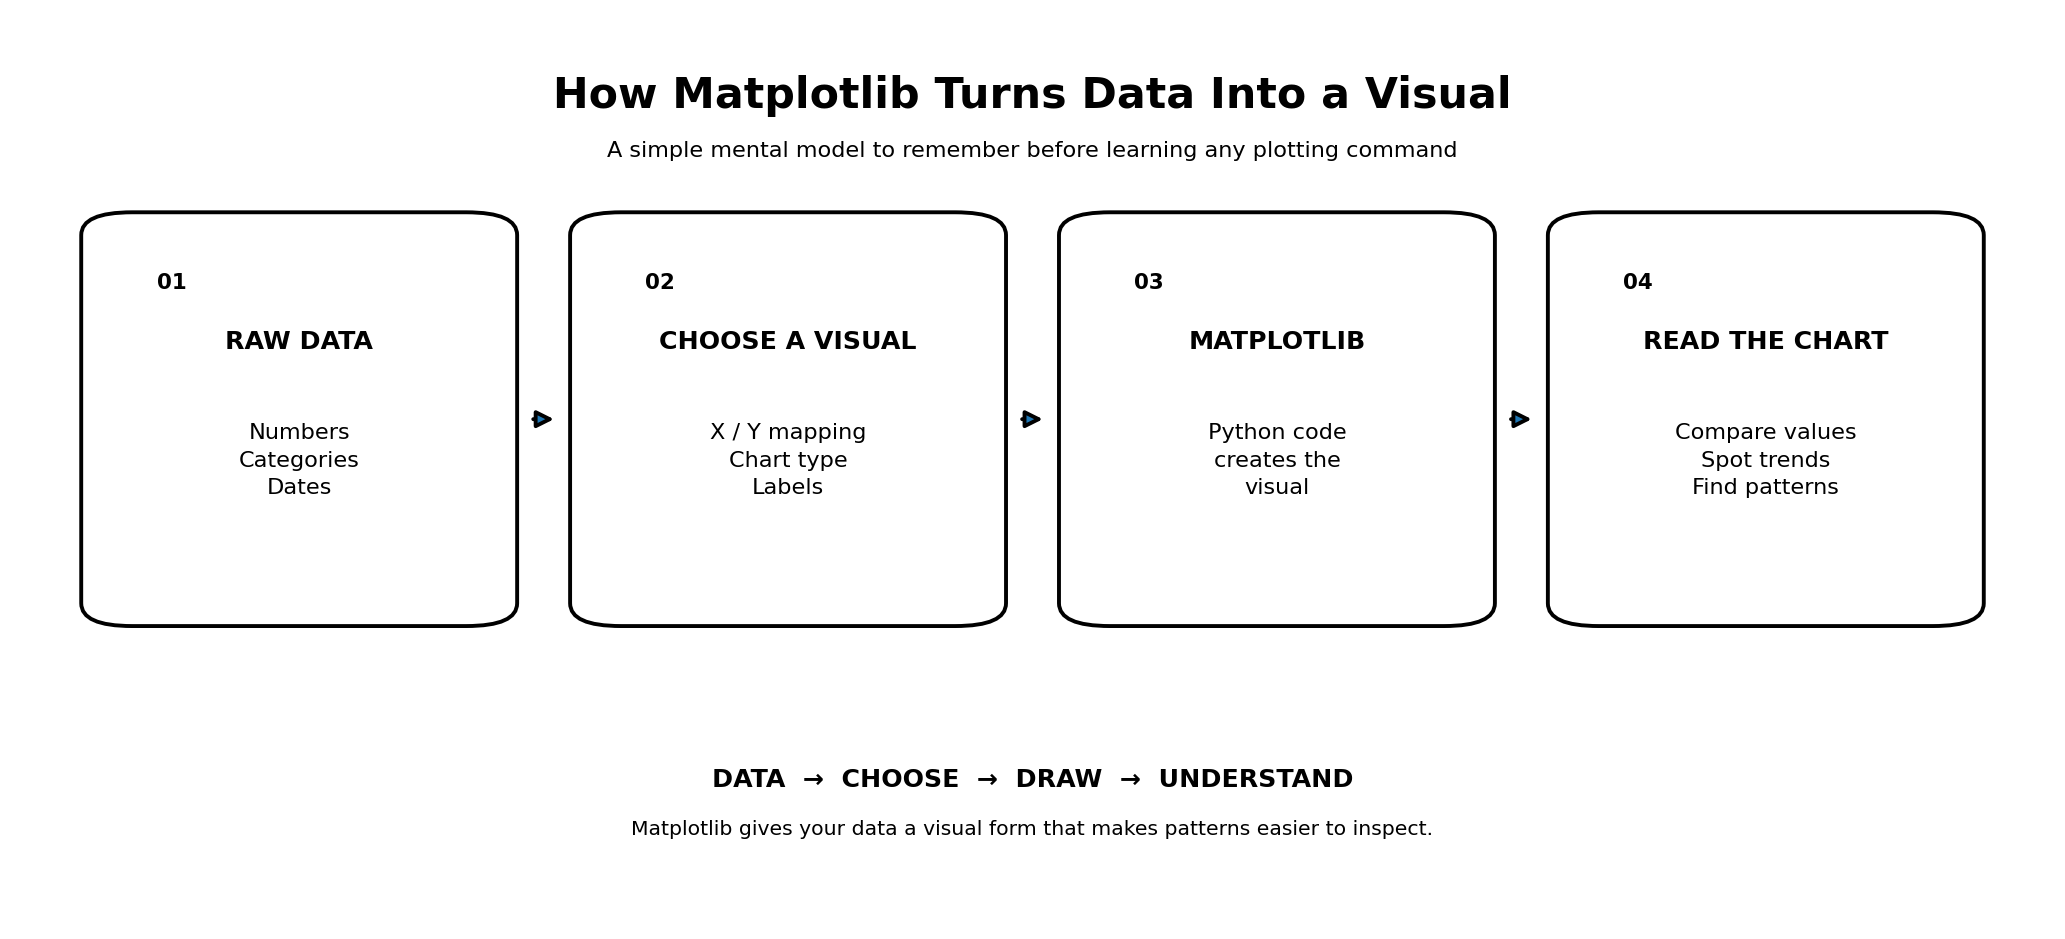

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(15, 7), dpi=140)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

stages = [
    ("01", "RAW DATA", "Numbers\nCategories\nDates"),
    ("02", "CHOOSE A VISUAL", "X / Y mapping\nChart type\nLabels"),
    ("03", "MATPLOTLIB", "Python code\ncreates the\nvisual"),
    ("04", "READ THE CHART", "Compare values\nSpot trends\nFind patterns"),
]
xs = [0.045, 0.285, 0.525, 0.765]
box_w, box_h, y = 0.19, 0.43, 0.34
for i, (num, title, desc) in enumerate(stages):
    x = xs[i]
    ax.add_patch(FancyBboxPatch((x, y), box_w, box_h, boxstyle="round,pad=0.012,rounding_size=0.025", linewidth=2.0, edgecolor="black", facecolor="white"))
    ax.text(x + 0.025, y + box_h - 0.065, num, ha="left", va="center", fontsize=11, fontweight="bold")
    ax.text(x + box_w/2, y + box_h - 0.13, title, ha="center", va="center", fontsize=13, fontweight="bold")
    ax.text(x + box_w/2, y + 0.17, desc, ha="center", va="center", fontsize=11.5, linespacing=1.45)
    if i < len(stages)-1:
        ax.annotate("", xy=(xs[i+1]-0.018, y+box_h/2), xytext=(x+box_w+0.018, y+box_h/2), arrowprops=dict(arrowstyle="-|>", linewidth=2.0, mutation_scale=18))
ax.text(0.5, 0.91, "How Matplotlib Turns Data Into a Visual", ha="center", va="center", fontsize=22, fontweight="bold")
ax.text(0.5, 0.85, "A simple mental model to remember before learning any plotting command", ha="center", va="center", fontsize=11.5)
ax.text(0.5, 0.16, "DATA  →  CHOOSE  →  DRAW  →  UNDERSTAND", ha="center", va="center", fontsize=13, fontweight="bold")
ax.text(0.5, 0.105, "Matplotlib gives your data a visual form that makes patterns easier to inspect.", ha="center", va="center", fontsize=10.5)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis("off"); fig.subplots_adjust(left=0.015,right=0.985,top=0.97,bottom=0.04); plt.show()


### Visual mental model

The diagram above shows the core idea behind Matplotlib: **data becomes useful when a visual representation helps us reason about it.** We first identify the information, decide how it should be mapped to visual elements, render the chart, and then inspect the resulting pattern.

- **Data:** raw values, categories, or measurements.
- **Mapping:** the decision that connects data to visual elements such as x-position, y-position, bar length, marker position, or color.
- **Visual:** the chart Matplotlib renders from those instructions.
- **Insight:** a pattern, comparison, trend, or relationship that becomes easier to recognize.

This idea will guide the entire class: **we are not learning Matplotlib only to make charts; we are learning it to communicate and analyze data clearly.**

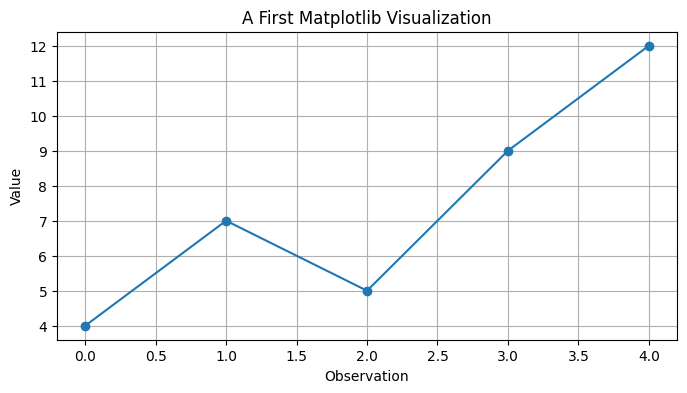

In [3]:
values = [4, 7, 5, 9, 12]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(values, marker="o")
ax.set_title("A First Matplotlib Visualization")
ax.set_xlabel("Observation")
ax.set_ylabel("Value")
ax.grid(True)
plt.show()

# Module 2 — Installing, Importing, and Checking Matplotlib

A typical installation is:

```bash
pip install matplotlib
```

The most common import is:

```python
import matplotlib.pyplot as plt
```

Checking the installed version can help diagnose environment problems.

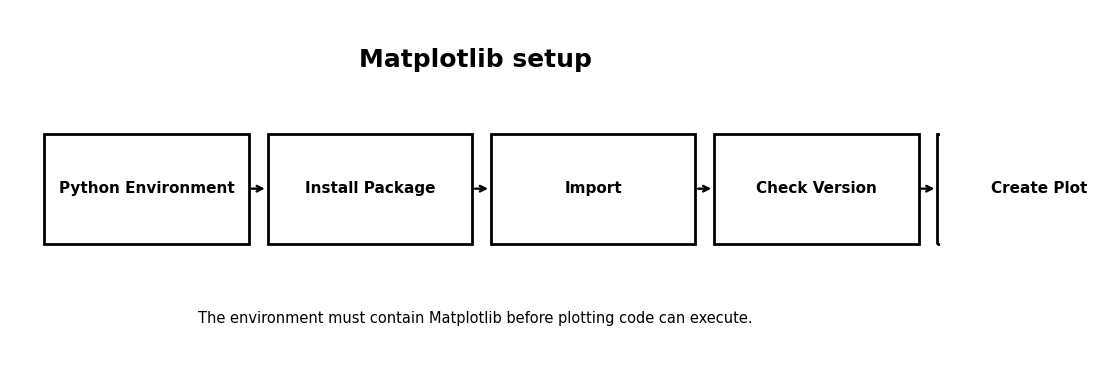

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Python Environment', 'Install Package', 'Import', 'Check Version', 'Create Plot']
n = len(steps)
left = 0.037
box_w = 1.2 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Matplotlib setup', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'The environment must contain Matplotlib before plotting code can execute.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

In [5]:
import matplotlib.pyplot as plt
print("Matplotlib is available.")
print("Version:", plt.matplotlib.__version__)

Matplotlib is available.
Version: 3.10.8


# Module 3 — The Matplotlib Object Model

Four ideas are especially important:

- **Figure** — the complete canvas
- **Axes** — an individual plotting region
- **Axis** — the x/y coordinate system inside an Axes
- **Artists** — visual elements such as lines, text, patches, and markers

A Figure can contain many Axes.

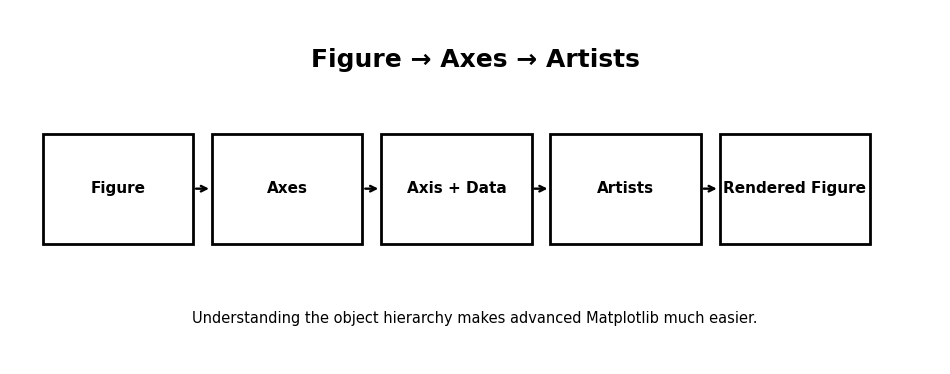

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Figure', 'Axes', 'Axis + Data', 'Artists', 'Rendered Figure']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Figure → Axes → Artists', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Understanding the object hierarchy makes advanced Matplotlib much easier.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

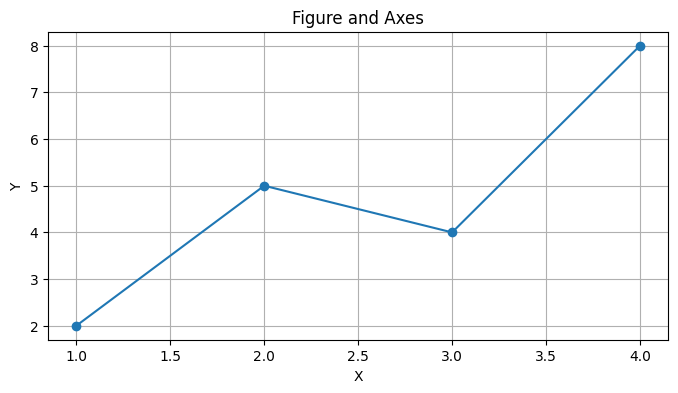

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([1, 2, 3, 4], [2, 5, 4, 8], marker="o")
ax.set_title("Figure and Axes")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True)
plt.show()

# Module 4 — The Basic Plotting Workflow

A reliable workflow is:

1. prepare data
2. create a Figure and Axes
3. plot the data
4. add context
5. inspect the result
6. refine the design
7. save or display it

This sequence is more valuable than memorizing isolated commands.

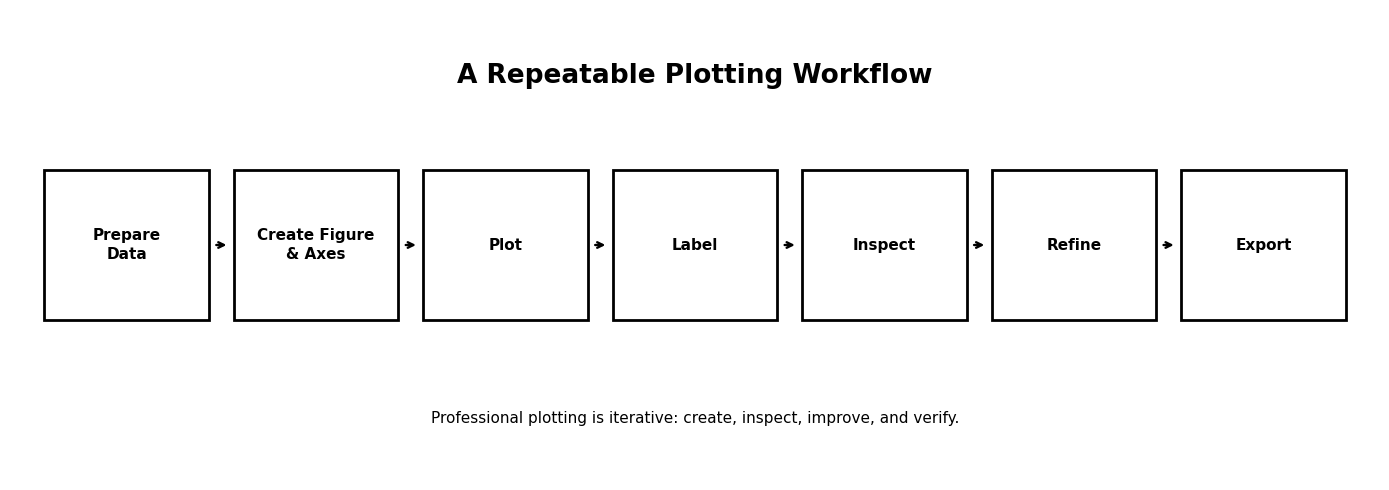

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 5))

# Short, readable labels
steps = [
    "Prepare\nData",
    "Create Figure\n& Axes",
    "Plot",
    "Label",
    "Inspect",
    "Refine",
    "Export"
]

n = len(steps)

# Layout
left = 0.025
right = 0.975
gap = 0.018

total_width = right - left
box_w = (total_width - gap * (n - 1)) / n

box_y = 0.34
box_h = 0.32

# Draw boxes and arrows
for i, label in enumerate(steps):

    x = left + i * (box_w + gap)

    # Box
    ax.add_patch(
        Rectangle(
            (x, box_y),
            box_w,
            box_h,
            fill=False,
            linewidth=2
        )
    )

    # Text inside box
    ax.text(
        x + box_w / 2,
        box_y + box_h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        linespacing=1.3
    )

    # Arrow
    if i < n - 1:
        ax.annotate(
            "",
            xy=(x + box_w + gap * 0.82, box_y + box_h / 2),
            xytext=(x + box_w + gap * 0.18, box_y + box_h / 2),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.7
            }
        )

# Main title
ax.text(
    0.5,
    0.86,
    "A Repeatable Plotting Workflow",
    ha="center",
    va="center",
    fontsize=19,
    fontweight="bold"
)

# Supporting explanation
ax.text(
    0.5,
    0.13,
    "Professional plotting is iterative: create, inspect, improve, and verify.",
    ha="center",
    va="center",
    fontsize=11
)

# Clean layout
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout()
plt.show()

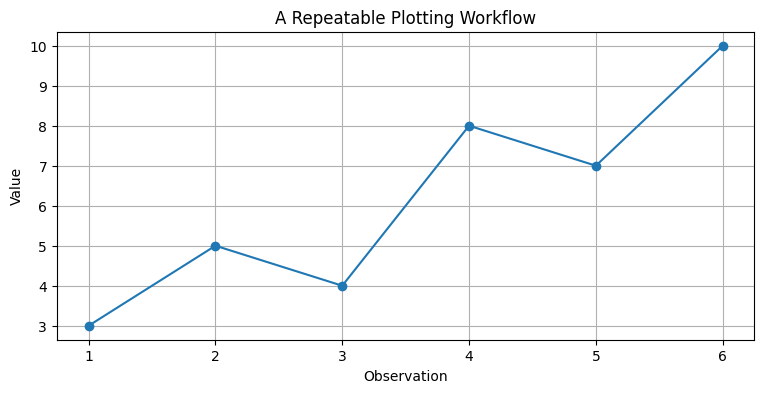

In [9]:
x = np.arange(1, 7)
y = [3, 5, 4, 8, 7, 10]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, marker="o")
ax.set_title("A Repeatable Plotting Workflow")
ax.set_xlabel("Observation")
ax.set_ylabel("Value")
ax.grid(True)
plt.show()

# Module 5 — Line Charts

Line charts are appropriate when observations have a meaningful order, especially time.

Important features:

- x-values
- y-values
- markers
- line style
- labels
- title
- grid
- legend when multiple series exist

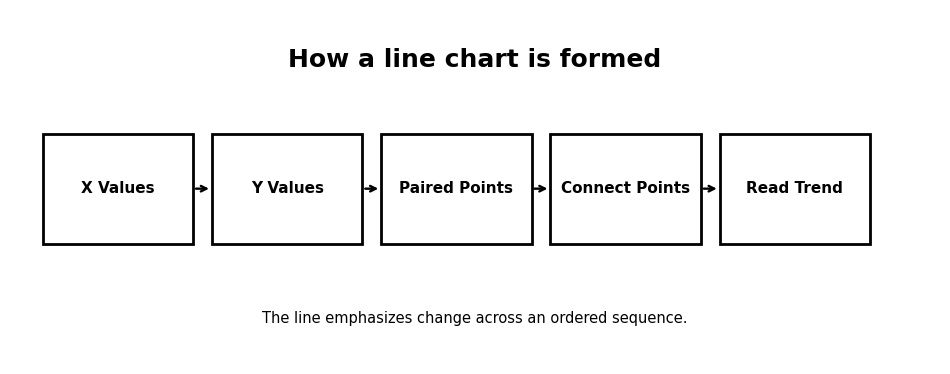

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['X Values', 'Y Values', 'Paired Points', 'Connect Points', 'Read Trend']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'How a line chart is formed', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'The line emphasizes change across an ordered sequence.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

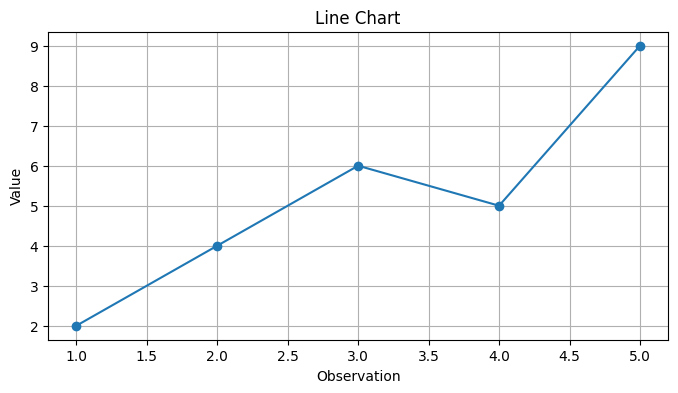

In [11]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 5, 9]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, marker="o")
ax.set_title("Line Chart")
ax.set_xlabel("Observation")
ax.set_ylabel("Value")
ax.grid(True)
plt.show()

# Module 6 — Bar and Horizontal Bar Charts

Bar charts compare separate categories.

Use:

- `ax.bar()` for vertical bars
- `ax.barh()` for horizontal bars

Horizontal bars are often easier to read when category names are long.

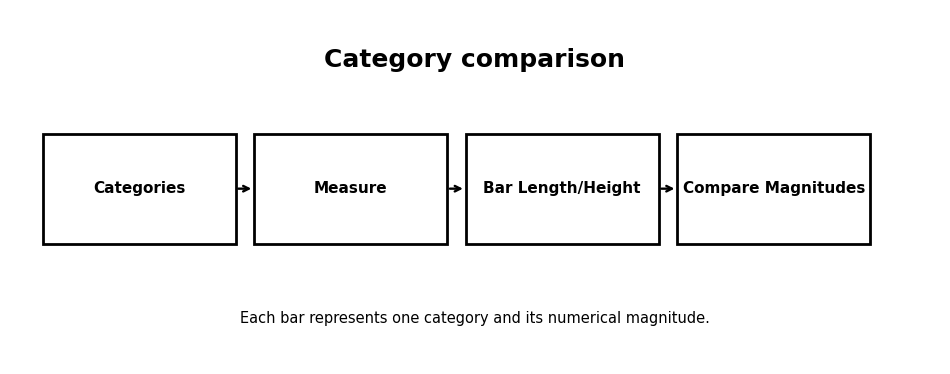

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Categories', 'Measure', 'Bar Length/Height', 'Compare Magnitudes']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Category comparison', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Each bar represents one category and its numerical magnitude.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

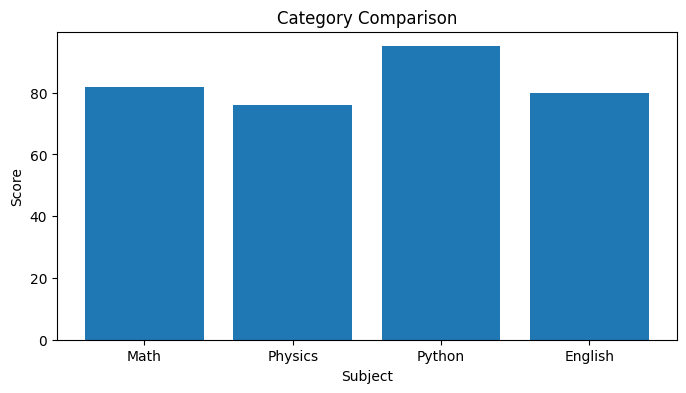

In [13]:
categories = ["Math", "Physics", "Python", "English"]
scores = [82, 76, 95, 80]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(categories, scores)
ax.set_title("Category Comparison")
ax.set_xlabel("Subject")
ax.set_ylabel("Score")
plt.show()

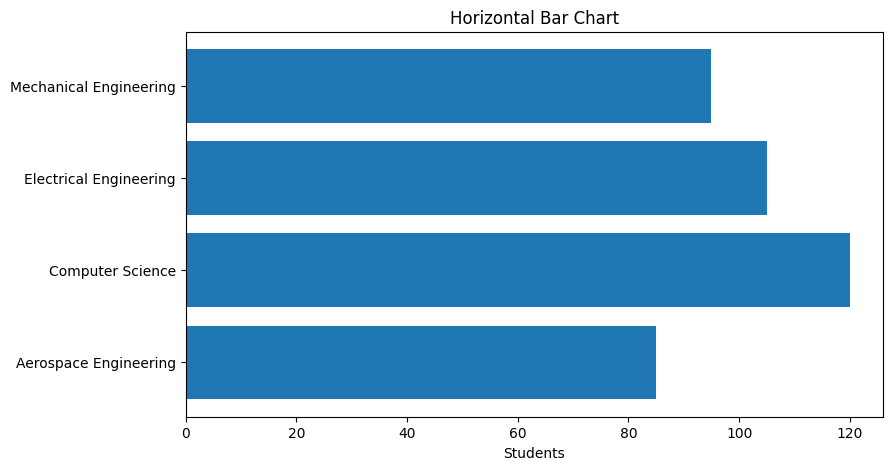

In [14]:
departments = ["Aerospace Engineering", "Computer Science",
               "Electrical Engineering", "Mechanical Engineering"]
students = [85, 120, 105, 95]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(departments, students)
ax.set_title("Horizontal Bar Chart")
ax.set_xlabel("Students")
plt.show()

# Module 7 — Scatter Plots and Correlation

Scatter plots show paired observations.

They are useful for investigating relationships between two numerical variables.

Look for:

- direction
- strength
- clusters
- unusual points

A visible relationship is not automatically proof of causation.

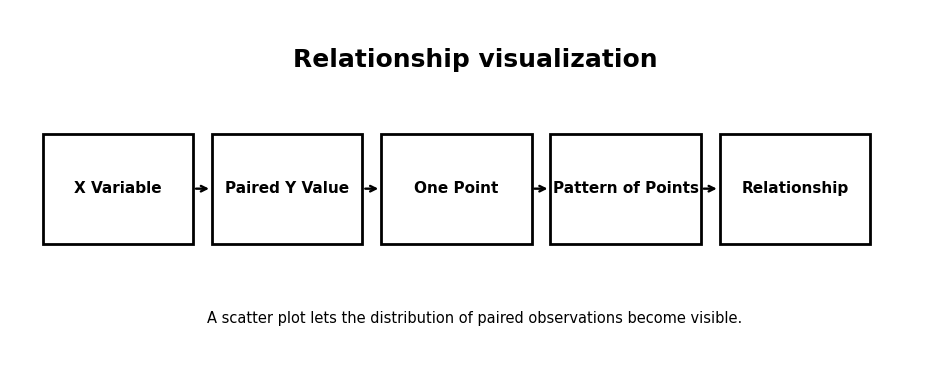

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['X Variable', 'Paired Y Value', 'One Point', 'Pattern of Points', 'Relationship']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Relationship visualization', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'A scatter plot lets the distribution of paired observations become visible.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

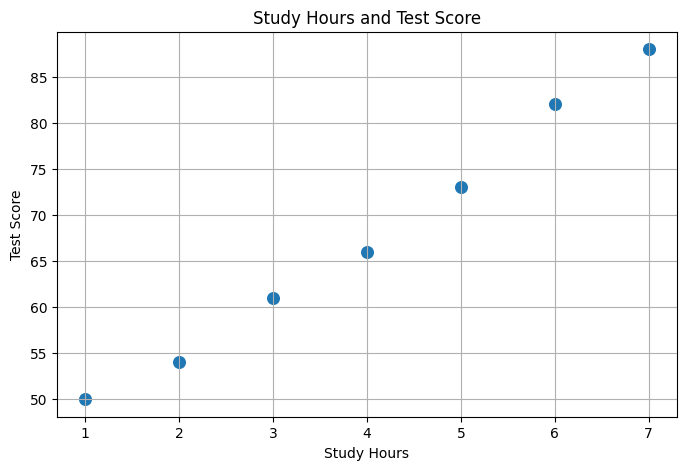

In [16]:
hours = np.array([1, 2, 3, 4, 5, 6, 7])
scores = np.array([50, 54, 61, 66, 73, 82, 88])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(hours, scores, s=70)
ax.set_title("Study Hours and Test Score")
ax.set_xlabel("Study Hours")
ax.set_ylabel("Test Score")
ax.grid(True)
plt.show()

# Module 8 — Histograms and Bins

A histogram groups numerical observations into intervals called **bins**.

It helps us inspect a distribution.

Important idea:

> The number of bins changes how much detail the distribution reveals.

Too few bins can hide structure; too many can make random variation look important.

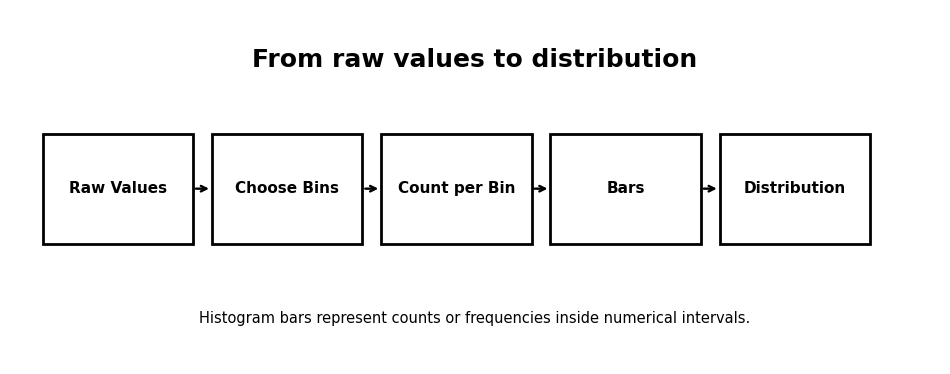

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Raw Values', 'Choose Bins', 'Count per Bin', 'Bars', 'Distribution']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'From raw values to distribution', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Histogram bars represent counts or frequencies inside numerical intervals.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

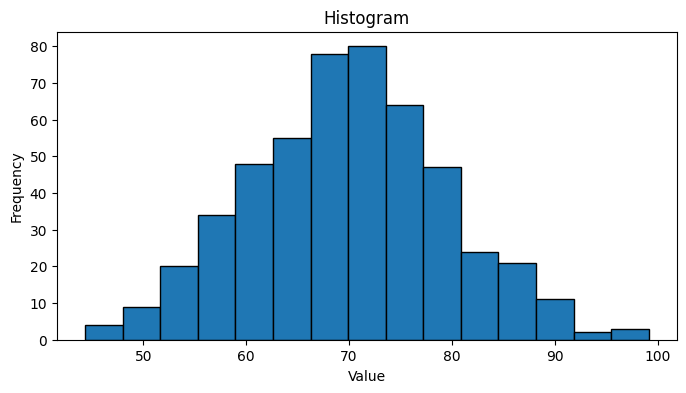

In [18]:
rng = np.random.default_rng(42)
values = rng.normal(70, 10, 500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(values, bins=15, edgecolor="black")
ax.set_title("Histogram")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
plt.show()

# Module 9 — Pie Charts

Pie charts show parts of a whole.

They are most effective when:

- there are few categories
- all categories belong to the same whole
- exact comparisons are not the main goal

For many categories, a bar chart is usually easier to compare.

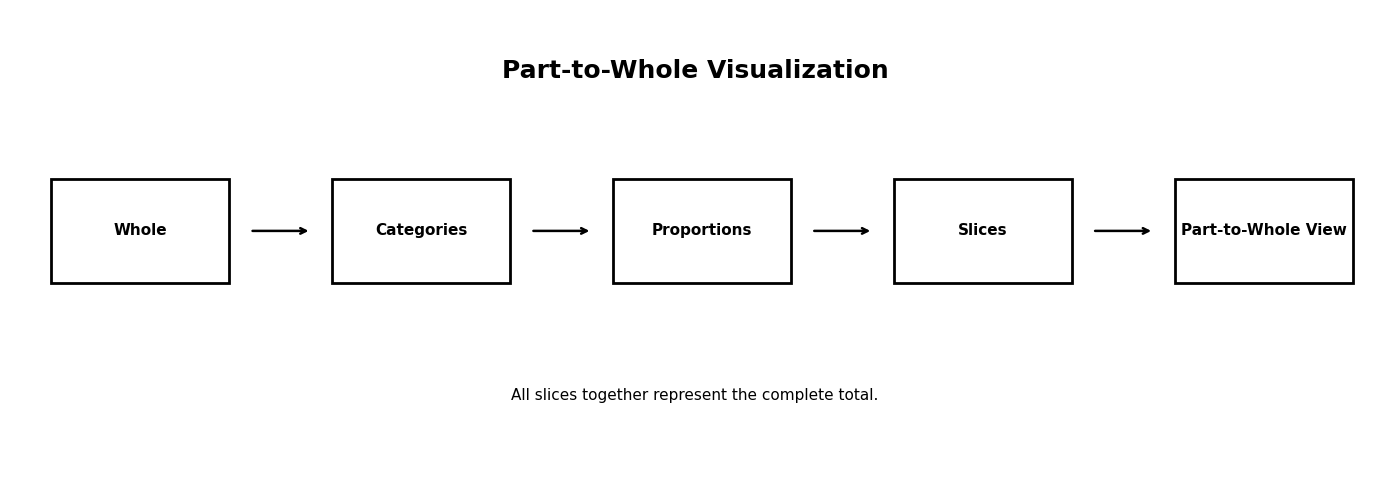

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

steps = [
    "Whole",
    "Categories",
    "Proportions",
    "Slices",
    "Part-to-Whole View"
]

# -----------------------------
# Layout settings
# -----------------------------
box_w = 0.13
box_h = 0.22
y = 0.42

# X positions manually set for perfect spacing
x_positions = [0.03, 0.235, 0.44, 0.645, 0.85]

# -----------------------------
# Draw boxes and arrows
# -----------------------------
for i, (x, label) in enumerate(zip(x_positions, steps)):

    # Box
    rect = plt.Rectangle(
        (x, y),
        box_w,
        box_h,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    # Text inside box
    ax.text(
        x + box_w / 2,
        y + box_h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    # Arrow
    if i < len(steps) - 1:
        arrow_start = x + box_w
        arrow_end = x_positions[i + 1]

        ax.annotate(
            "",
            xy=(arrow_end - 0.015, y + box_h / 2),
            xytext=(arrow_start + 0.015, y + box_h / 2),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.8
            }
        )

# -----------------------------
# Title
# -----------------------------
ax.text(
    0.5,
    0.87,
    "Part-to-Whole Visualization",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# -----------------------------
# Bottom explanation
# -----------------------------
ax.text(
    0.5,
    0.18,
    "All slices together represent the complete total.",
    ha="center",
    va="center",
    fontsize=11
)

# -----------------------------
# Final formatting
# -----------------------------
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.axis("off")

plt.tight_layout()
plt.show()

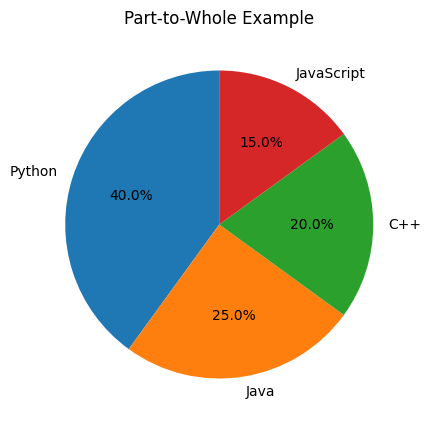

In [20]:
labels = ["Python", "Java", "C++", "JavaScript"]
values = [40, 25, 20, 15]

fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
ax.set_title("Part-to-Whole Example")
plt.show()

# Module 10 — Box Plots and Violin Plots

A box plot summarizes distribution using quartiles, median, spread, and possible outliers.

A violin plot adds a view of the distribution shape.

These plots are especially useful when comparing groups.

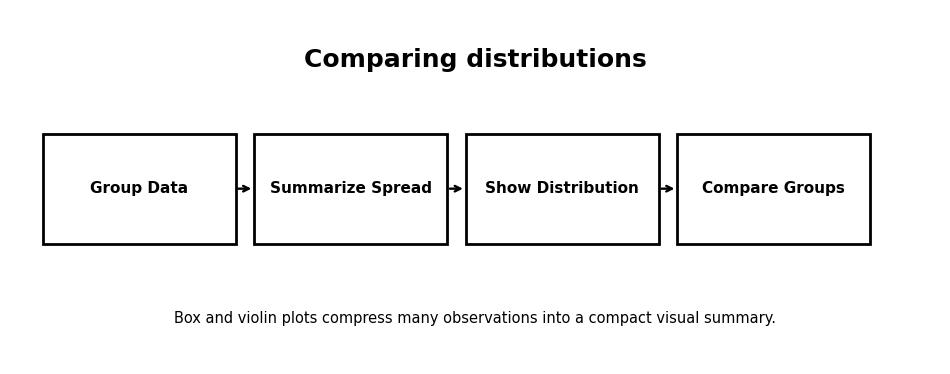

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Group Data', 'Summarize Spread', 'Show Distribution', 'Compare Groups']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Comparing distributions', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Box and violin plots compress many observations into a compact visual summary.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

/tmp/ipykernel_369/2681593596.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([group_a, group_b], labels=["Group A", "Group B"])


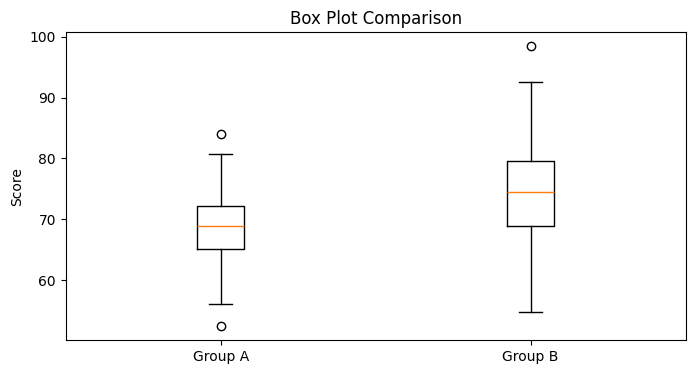

In [22]:
rng = np.random.default_rng(7)
group_a = rng.normal(70, 7, 80)
group_b = rng.normal(76, 10, 80)

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([group_a, group_b], labels=["Group A", "Group B"])
ax.set_title("Box Plot Comparison")
ax.set_ylabel("Score")
plt.show()

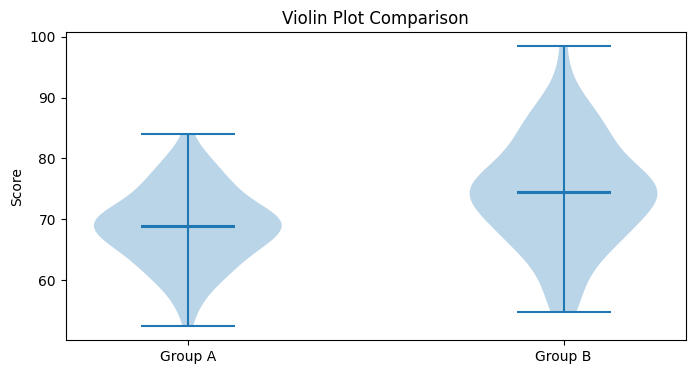

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.violinplot([group_a, group_b], showmeans=True, showmedians=True)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Group A", "Group B"])
ax.set_title("Violin Plot Comparison")
ax.set_ylabel("Score")
plt.show()

# Module 11 — Markers, Line Styles, Width, and Transparency

Matplotlib supports visual properties such as:

- `marker`
- `linestyle`
- `linewidth`
- `markersize`
- `alpha`

These should improve readability rather than create visual noise.

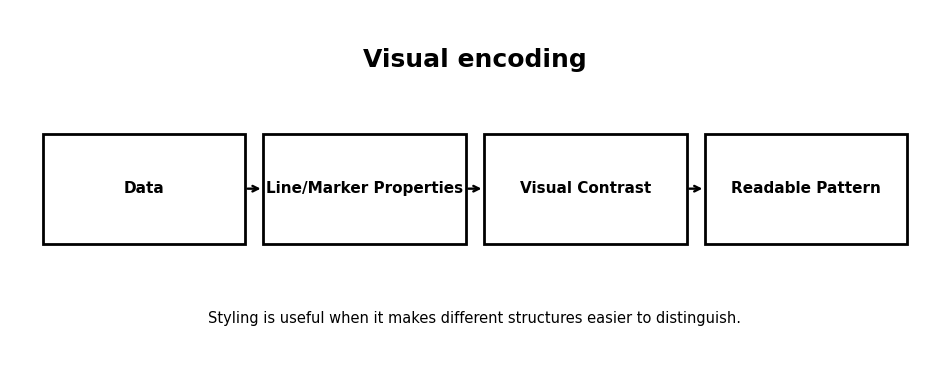

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Data', 'Line/Marker Properties', 'Visual Contrast', 'Readable Pattern']
n = len(steps)
left = 0.035
box_w = 0.95 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Visual encoding', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Styling is useful when it makes different structures easier to distinguish.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

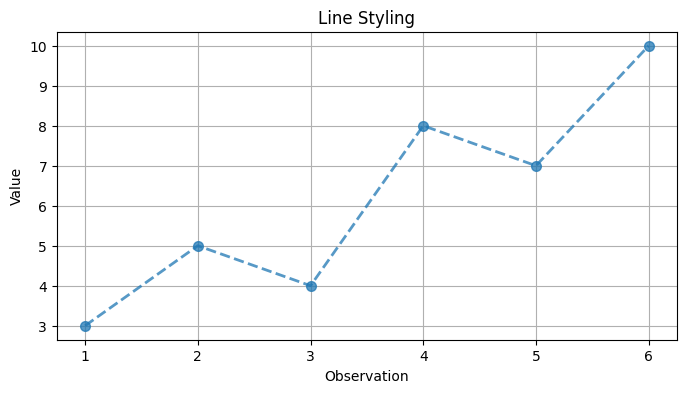

In [25]:
x = np.arange(1, 7)
y = [3, 5, 4, 8, 7, 10]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, marker="o", linestyle="--", linewidth=2,
        markersize=7, alpha=0.75)
ax.set_title("Line Styling")
ax.set_xlabel("Observation")
ax.set_ylabel("Value")
ax.grid(True)
plt.show()

# Module 12 — Titles, Labels, Legends, Ticks, Limits, and Annotations

A chart can be technically correct and still be difficult to understand.

Core tools include:

- `set_title()`
- `set_xlabel()`
- `set_ylabel()`
- `legend()`
- `set_xlim()`
- `set_ylim()`
- `set_xticks()`
- `set_yticks()`
- `annotate()`

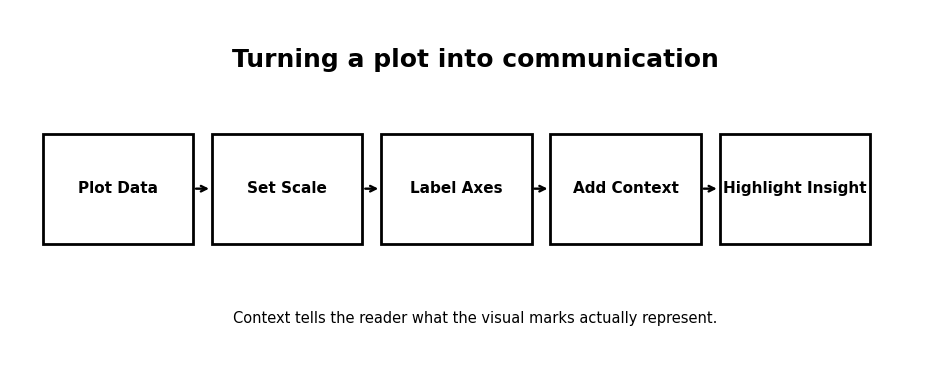

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Plot Data', 'Set Scale', 'Label Axes', 'Add Context', 'Highlight Insight']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Turning a plot into communication', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Context tells the reader what the visual marks actually represent.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

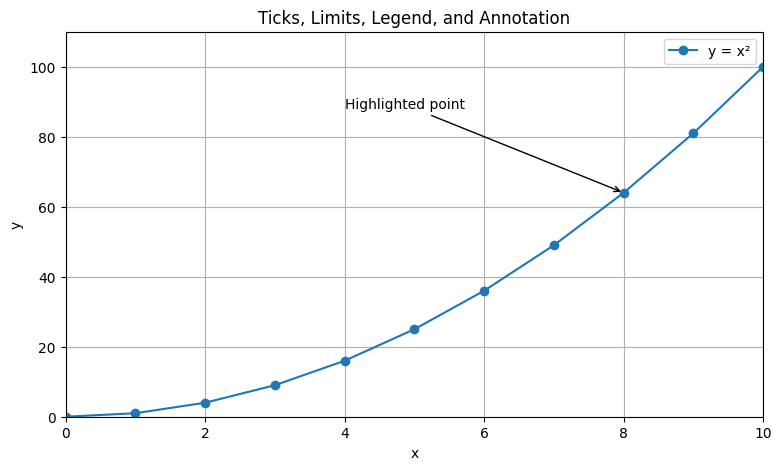

In [27]:
x = np.arange(0, 11)
y = x ** 2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, marker="o", label="y = x²")
ax.set_title("Ticks, Limits, Legend, and Annotation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_xlim(0, 10)
ax.set_ylim(0, 110)
ax.set_xticks(range(0, 11, 2))
ax.legend()
ax.grid(True)

ax.annotate(
    "Highlighted point",
    xy=(8, 64),
    xytext=(4, 88),
    arrowprops={"arrowstyle": "->"}
)

plt.show()

# Module 13 — Subplots and Shared Axes

A single Figure can contain several Axes.

`plt.subplots()` is the most common way to build a grid of plots.

Shared axes can make comparisons easier when multiple plots use the same scale.

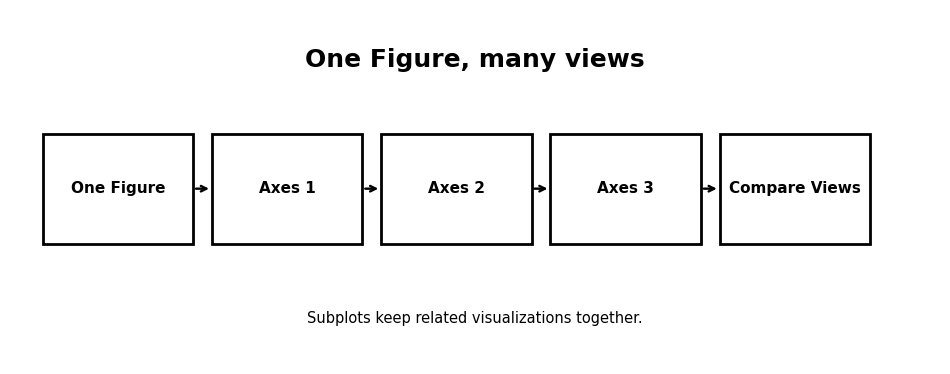

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['One Figure', 'Axes 1', 'Axes 2', 'Axes 3', 'Compare Views']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'One Figure, many views', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Subplots keep related visualizations together.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

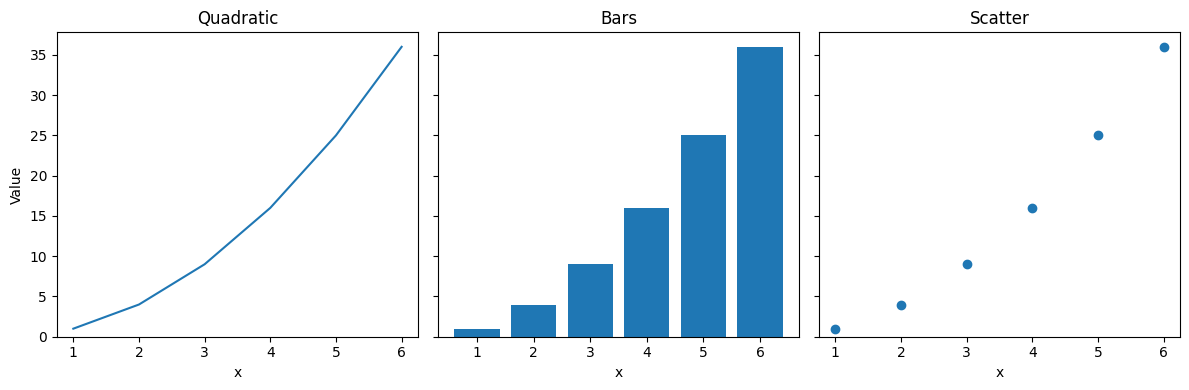

In [29]:
x = np.arange(1, 7)

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

axes[0].plot(x, x**2)
axes[0].set_title("Quadratic")

axes[1].bar(x, x**2)
axes[1].set_title("Bars")

axes[2].scatter(x, x**2)
axes[2].set_title("Scatter")

for ax in axes:
    ax.set_xlabel("x")
axes[0].set_ylabel("Value")

plt.tight_layout()
plt.show()

# Module 14 — Object-Oriented Matplotlib

The object-oriented style gives explicit control over Figure and Axes objects.

Typical pattern:

```python
fig, ax = plt.subplots()
ax.plot(...)
ax.set_title(...)
```

This approach becomes increasingly important as figures become more complex.

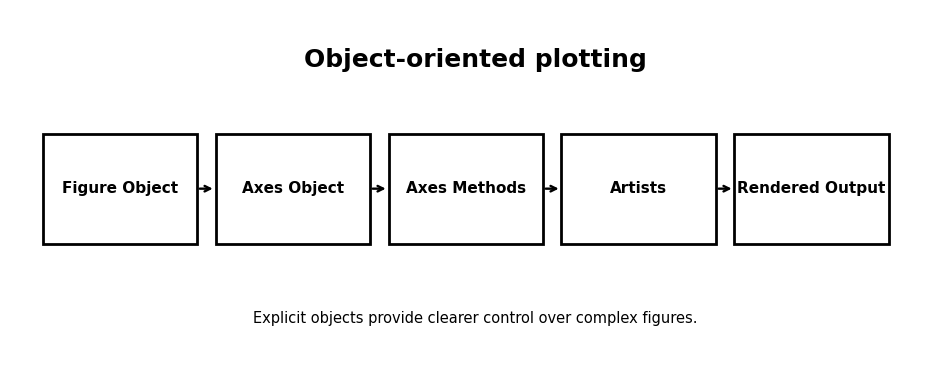

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Figure Object', 'Axes Object', 'Axes Methods', 'Artists', 'Rendered Output']
n = len(steps)
left = 0.035
box_w = 0.93 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Object-oriented plotting', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Explicit objects provide clearer control over complex figures.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

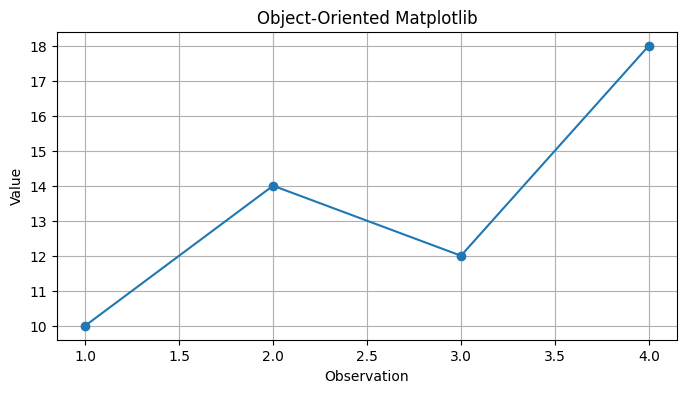

In [31]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot([1, 2, 3, 4], [10, 14, 12, 18], marker="o")
ax.set_title("Object-Oriented Matplotlib")
ax.set_xlabel("Observation")
ax.set_ylabel("Value")
ax.grid(True)
plt.show()

# Module 15 — NumPy + Matplotlib

NumPy is excellent for numerical arrays and mathematical calculations.

Matplotlib turns those arrays into visual representations.

This combination is useful for functions, simulations, distributions, and numerical experiments.

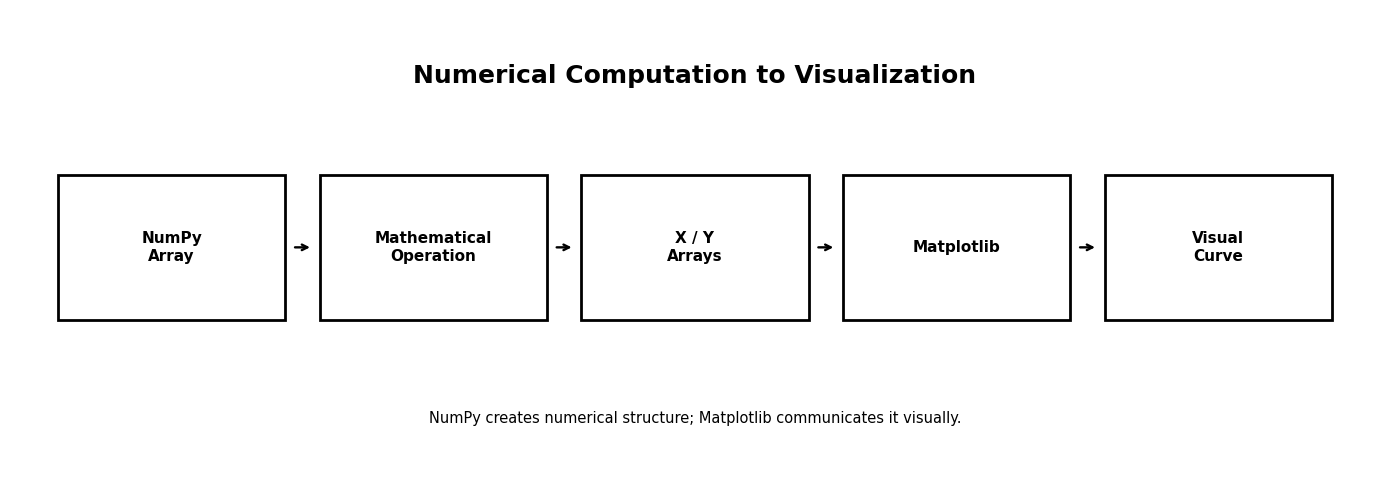

In [24]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 5))

steps = [
    "NumPy\nArray",
    "Mathematical\nOperation",
    "X / Y\nArrays",
    "Matplotlib",
    "Visual\nCurve"
]

n = len(steps)

# Layout settings
left = 0.035
right = 0.965
gap = 0.025

total_width = right - left
box_w = (total_width - gap * (n - 1)) / n

box_y = 0.34
box_h = 0.31

# Draw boxes and arrows
for i, label in enumerate(steps):

    x = left + i * (box_w + gap)

    # Draw box
    ax.add_patch(
        Rectangle(
            (x, box_y),
            box_w,
            box_h,
            fill=False,
            linewidth=2
        )
    )

    # Add centered text
    ax.text(
        x + box_w / 2,
        box_y + box_h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        linespacing=1.3
    )

    # Add arrow between boxes
    if i < n - 1:

        arrow_start = x + box_w
        arrow_end = x + box_w + gap

        ax.annotate(
            "",
            xy=(arrow_end - 0.005, box_y + box_h / 2),
            xytext=(arrow_start + 0.005, box_y + box_h / 2),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.7
            }
        )

# Title
ax.text(
    0.5,
    0.86,
    "Numerical Computation to Visualization",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# Explanation
ax.text(
    0.5,
    0.13,
    "NumPy creates numerical structure; Matplotlib communicates it visually.",
    ha="center",
    va="center",
    fontsize=10.5
)

# Clean canvas
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout()
plt.show()

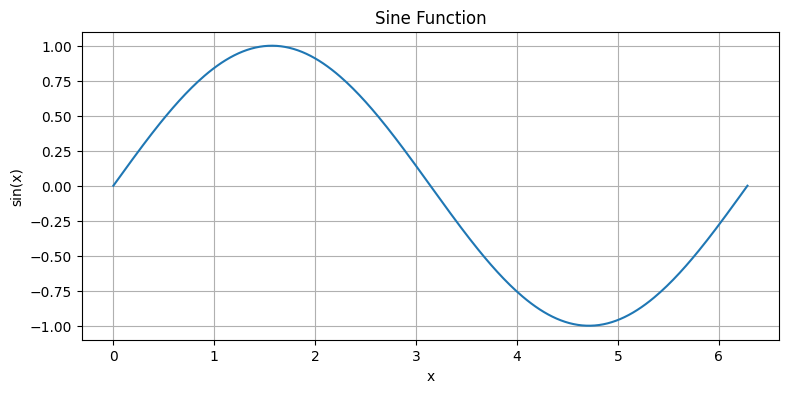

In [33]:
x = np.linspace(0, 2*np.pi, 300)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y)
ax.set_title("Sine Function")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")
ax.grid(True)
plt.show()

# Module 16 — Pandas + Matplotlib

Pandas stores structured data in Series and DataFrames.

Matplotlib can visualize selected DataFrame columns directly.

A useful analytical pipeline is:

**DataFrame → select variables → choose chart → visualize → interpret**

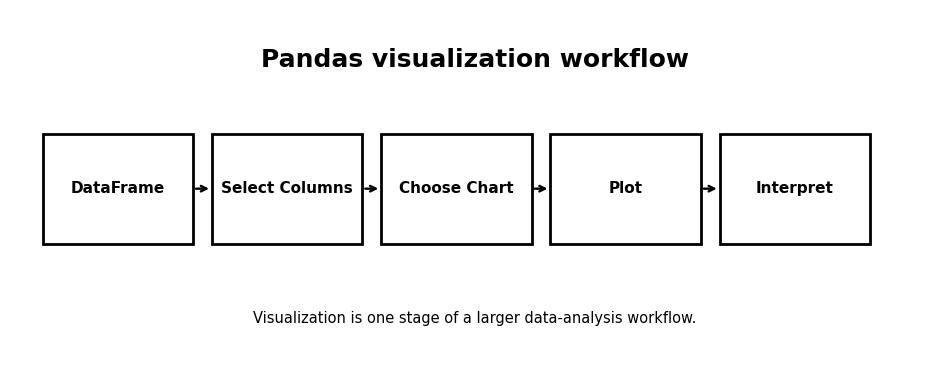

In [34]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['DataFrame', 'Select Columns', 'Choose Chart', 'Plot', 'Interpret']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Pandas visualization workflow', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Visualization is one stage of a larger data-analysis workflow.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

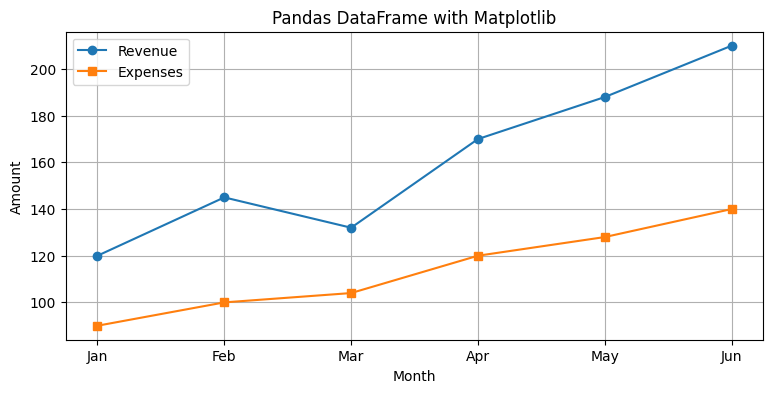

In [35]:
df = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Revenue": [120, 145, 132, 170, 188, 210],
    "Expenses": [90, 100, 104, 120, 128, 140]
})

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df["Month"], df["Revenue"], marker="o", label="Revenue")
ax.plot(df["Month"], df["Expenses"], marker="s", label="Expenses")
ax.set_title("Pandas DataFrame with Matplotlib")
ax.set_xlabel("Month")
ax.set_ylabel("Amount")
ax.legend()
ax.grid(True)
plt.show()

# Module 17 — Heatmaps with `imshow()`

A heatmap represents a matrix as colored cells.

`imshow()` is one of Matplotlib's core tools for displaying 2D numerical arrays.

Heatmaps are useful for:

- correlation matrices
- confusion matrices
- image-like numerical grids
- spatial intensity
- activity matrices

The values are represented through a **colormap**.

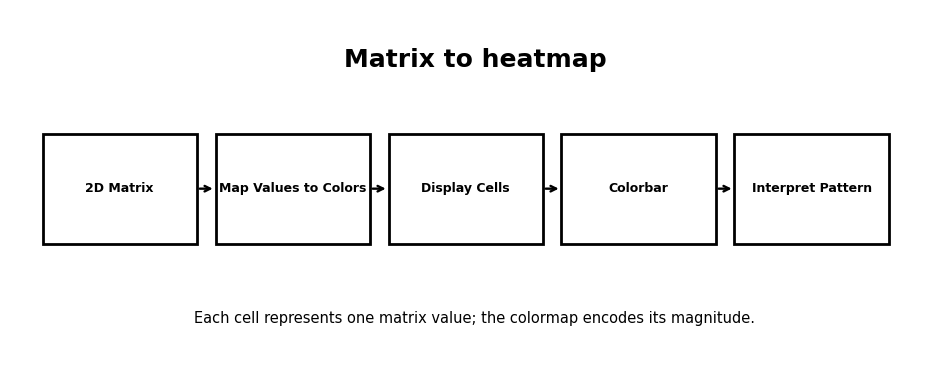

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['2D Matrix', 'Map Values to Colors', 'Display Cells', 'Colorbar', 'Interpret Pattern']
n = len(steps)
left = 0.035
box_w = 0.93 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Matrix to heatmap', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Each cell represents one matrix value; the colormap encodes its magnitude.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

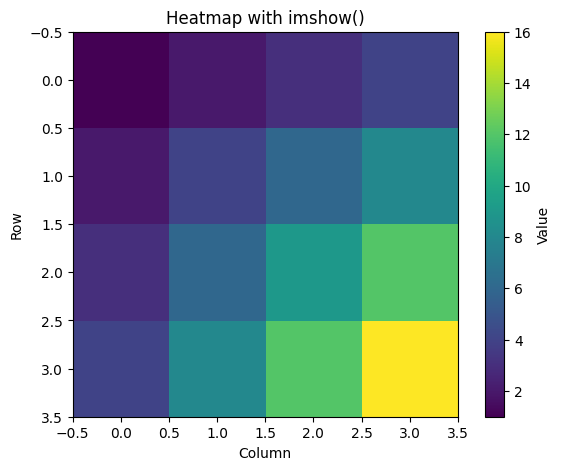

In [37]:
matrix = np.array([
    [1, 2, 3, 4],
    [2, 4, 6, 8],
    [3, 6, 9, 12],
    [4, 8, 12, 16]
])

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(matrix, cmap="viridis")
fig.colorbar(image, ax=ax, label="Value")
ax.set_title("Heatmap with imshow()")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.show()

### Understanding `cmap` and `colorbar()`

- `cmap` chooses the mapping from numerical values to colors.
- `imshow()` displays the 2D array.
- `colorbar()` provides the numerical legend for the color scale.

A heatmap without a clear color scale can be difficult to interpret.

# Module 18 — Correlation Matrices and Heatmap Analysis

A correlation matrix summarizes pairwise linear relationships between numerical variables.

A heatmap is a natural way to display it because the matrix contains many values.

Remember: **correlation does not establish causation.**

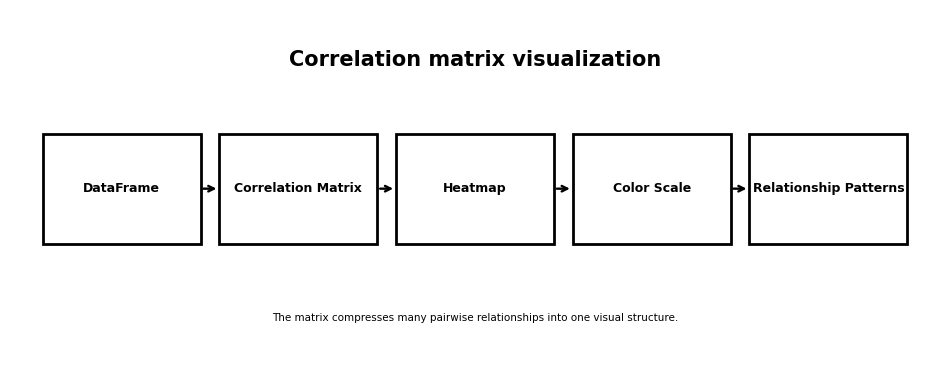

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['DataFrame', 'Correlation Matrix', 'Heatmap', 'Color Scale', 'Relationship Patterns']
n = len(steps)
left = 0.035
box_w = 0.95 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Correlation matrix visualization', ha="center", va="center",
        fontsize=15, fontweight="bold")
ax.text(0.5, 0.13, 'The matrix compresses many pairwise relationships into one visual structure.', ha="center", va="center",
        fontsize=7.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

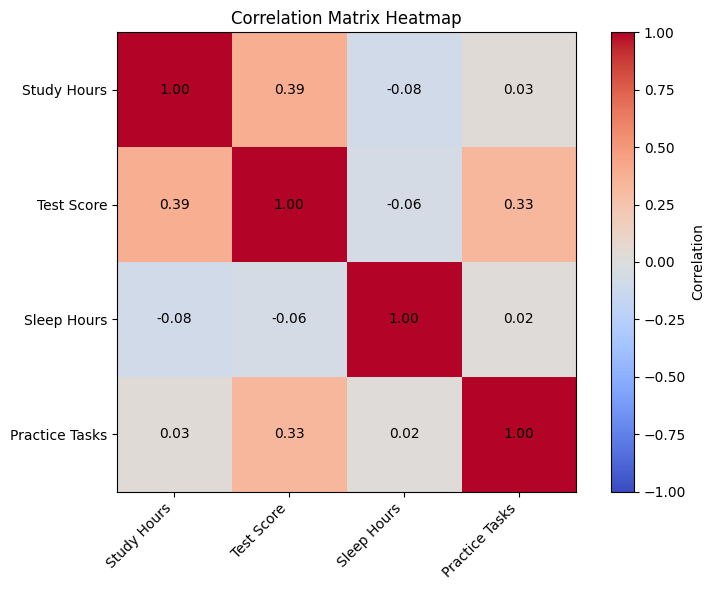

In [39]:
rng = np.random.default_rng(12)

data = pd.DataFrame({
    "Study Hours": rng.normal(5, 1.5, 120),
    "Test Score": rng.normal(70, 10, 120),
    "Sleep Hours": rng.normal(7, 0.8, 120),
    "Practice Tasks": rng.normal(12, 3, 120)
})

data["Test Score"] += data["Study Hours"] * 4
data["Test Score"] += data["Practice Tasks"] * 1.2

corr = data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(image, ax=ax, label="Correlation")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation Matrix Heatmap")

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center")

plt.tight_layout()
plt.show()

# Module 19 — `pcolormesh()` and Continuous Grids

`pcolormesh()` is useful when values correspond to cells in a coordinate grid.

It is especially useful when the x and y coordinates have real meaning.

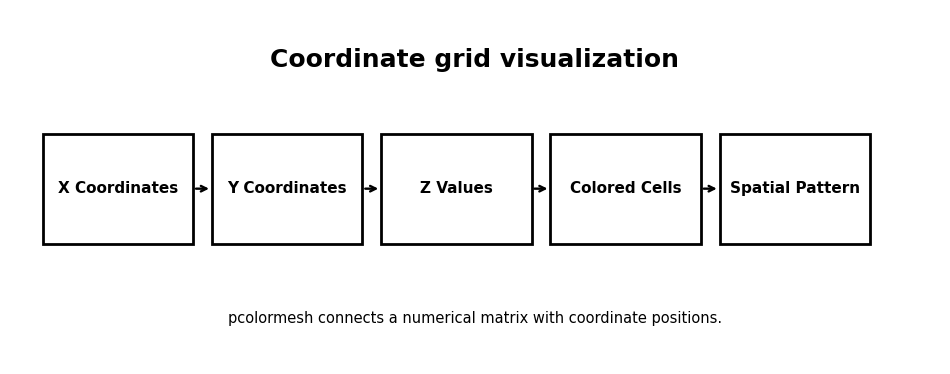

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['X Coordinates', 'Y Coordinates', 'Z Values', 'Colored Cells', 'Spatial Pattern']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Coordinate grid visualization', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'pcolormesh connects a numerical matrix with coordinate positions.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

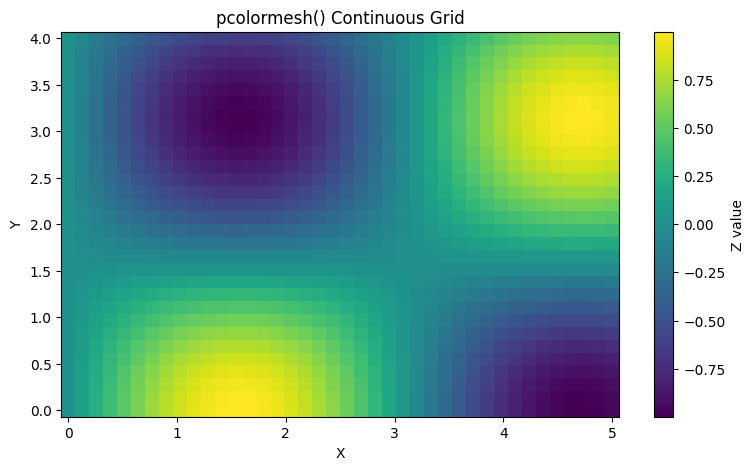

In [41]:
x = np.linspace(0, 5, 40)
y = np.linspace(0, 4, 30)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

fig, ax = plt.subplots(figsize=(9, 5))
mesh = ax.pcolormesh(X, Y, Z, shading="auto", cmap="viridis")
fig.colorbar(mesh, ax=ax, label="Z value")
ax.set_title("pcolormesh() Continuous Grid")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

# Module 20 — `fill_between()` and Confidence-Style Bands

`fill_between()` shades the area between two curves.

Common uses include:

- uncertainty bands
- forecast ranges
- upper/lower limits
- acceptable ranges
- variability around a trend

The shaded region should have a clear analytical meaning.

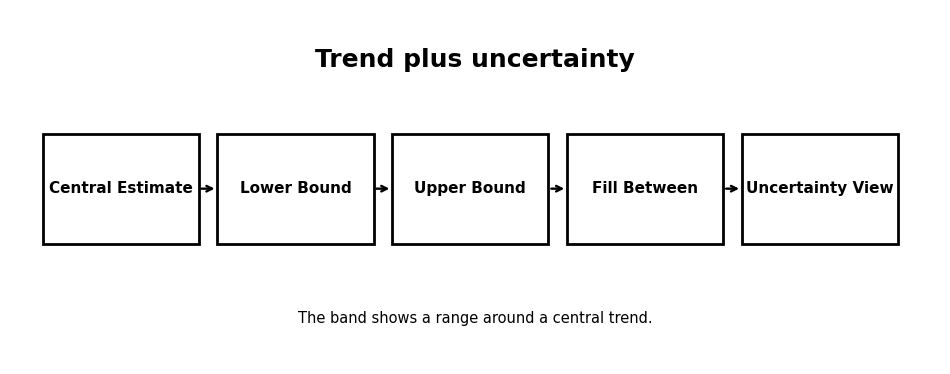

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Central Estimate', 'Lower Bound', 'Upper Bound', 'Fill Between', 'Uncertainty View']
n = len(steps)
left = 0.035
box_w = 0.94/ n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Trend plus uncertainty', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'The band shows a range around a central trend.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

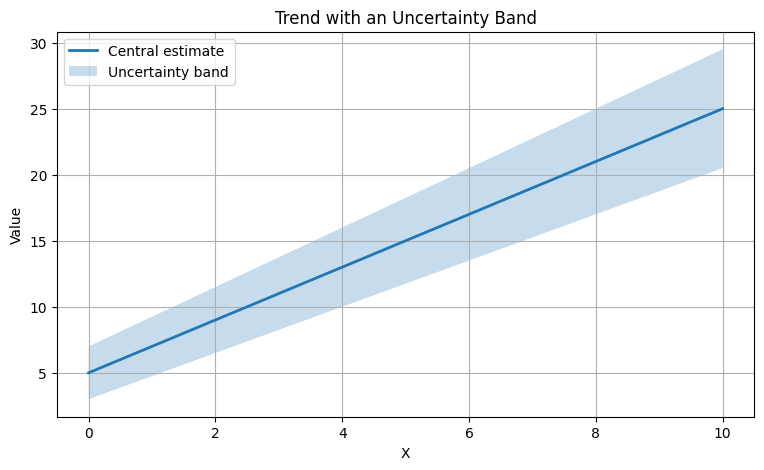

In [43]:
x = np.linspace(0, 10, 100)
mean = 2*x + 5
spread = 2 + 0.25*x
lower = mean - spread
upper = mean + spread

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, mean, linewidth=2, label="Central estimate")
ax.fill_between(x, lower, upper, alpha=0.25, label="Uncertainty band")
ax.set_title("Trend with an Uncertainty Band")
ax.set_xlabel("X")
ax.set_ylabel("Value")
ax.legend()
ax.grid(True)
plt.show()

# Module 21 — `errorbar()` and Uncertainty

Error bars communicate uncertainty or variation around measurements.

Common forms include:

- standard deviation
- standard error
- measurement uncertainty
- confidence intervals

The numerical meaning of the error bars must always be documented.

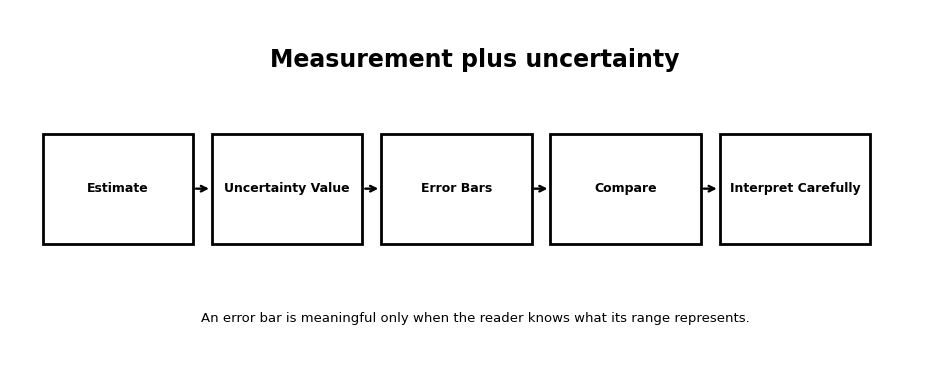

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Estimate', 'Uncertainty Value', 'Error Bars', 'Compare', 'Interpret Carefully']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Measurement plus uncertainty', ha="center", va="center",
        fontsize=17, fontweight="bold")
ax.text(0.5, 0.13, 'An error bar is meaningful only when the reader knows what its range represents.', ha="center", va="center",
        fontsize=9.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

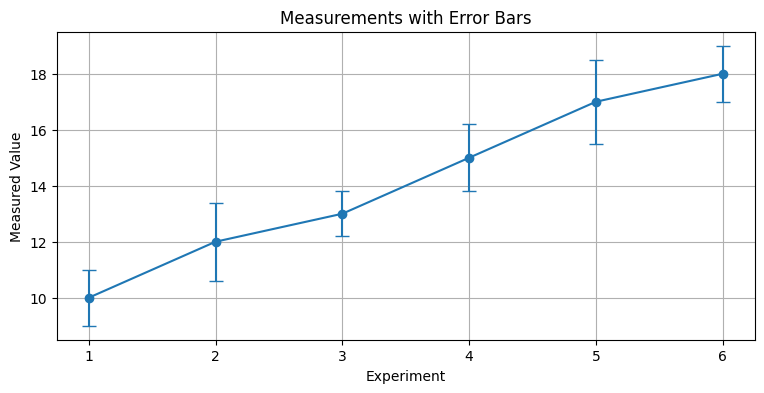

In [45]:
x = np.arange(1, 7)
means = np.array([10, 12, 13, 15, 17, 18])
errors = np.array([1.0, 1.4, 0.8, 1.2, 1.5, 1.0])

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(x, means, yerr=errors, fmt="o-", capsize=5)
ax.set_title("Measurements with Error Bars")
ax.set_xlabel("Experiment")
ax.set_ylabel("Measured Value")
ax.grid(True)
plt.show()

# Module 22 — `stackplot()` and Stacked Area Charts

A stacked area chart shows how components contribute to a total across an ordered dimension such as time.

It can communicate both:

- total magnitude
- changing composition

The categories should remain interpretable and not become too numerous.

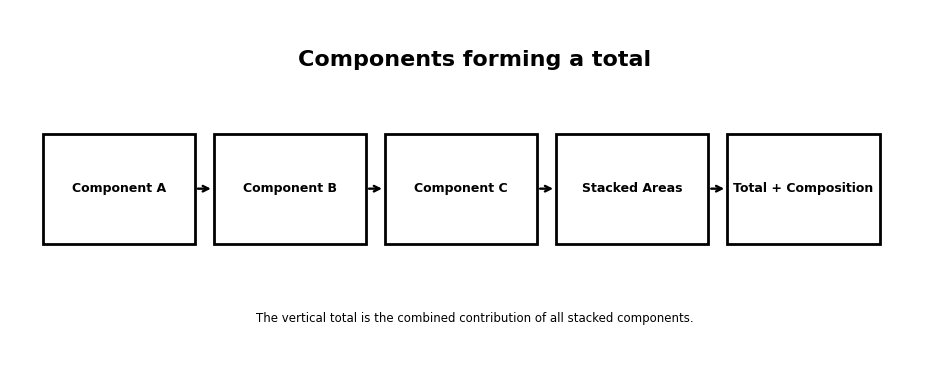

In [40]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Component A', 'Component B', 'Component C', 'Stacked Areas', 'Total + Composition']
n = len(steps)
left = 0.035
box_w = 0.92 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Components forming a total', ha="center", va="center",
        fontsize=16, fontweight="bold")
ax.text(0.5, 0.13, 'The vertical total is the combined contribution of all stacked components.', ha="center", va="center",
        fontsize=8.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

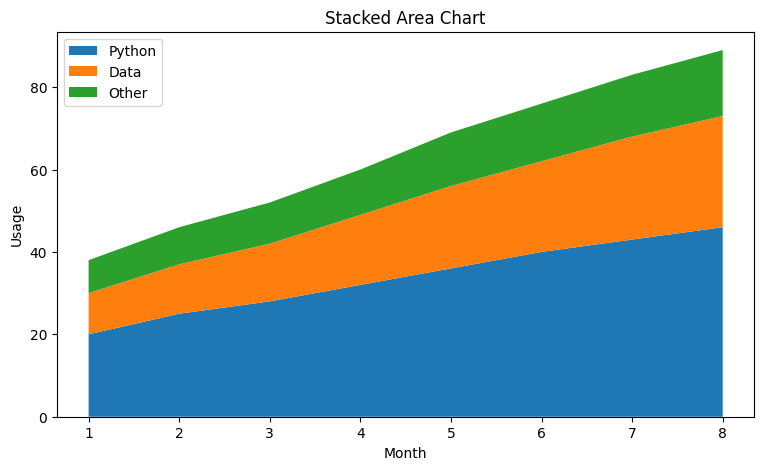

In [47]:
months = np.arange(1, 9)
python_use = np.array([20, 25, 28, 32, 36, 40, 43, 46])
data_use = np.array([10, 12, 14, 17, 20, 22, 25, 27])
other_use = np.array([8, 9, 10, 11, 13, 14, 15, 16])

fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(months, python_use, data_use, other_use,
             labels=["Python", "Data", "Other"])
ax.set_title("Stacked Area Chart")
ax.set_xlabel("Month")
ax.set_ylabel("Usage")
ax.legend(loc="upper left")
plt.show()

# Module 23 — Dual-Axis Charts with `twinx()`

Sometimes two variables share the same x-axis but have different units.

Example:

- revenue in dollars
- growth in percent

`twinx()` creates a second y-axis.

Dual axes must be used carefully because different scales can make relationships look stronger or weaker than they really are.

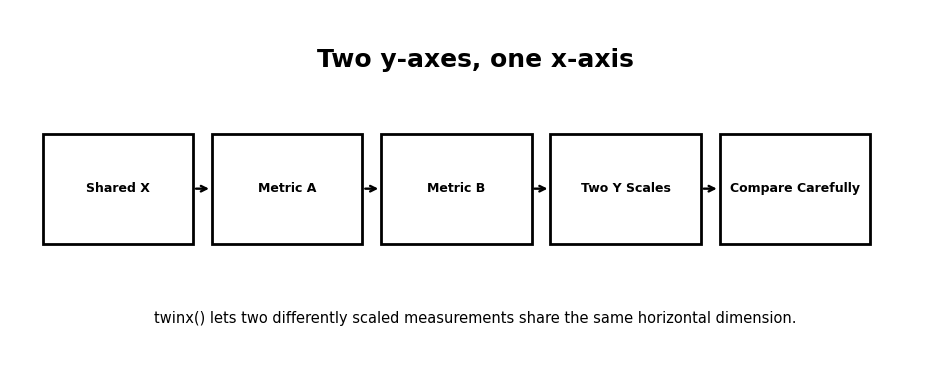

In [41]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Shared X', 'Metric A', 'Metric B', 'Two Y Scales', 'Compare Carefully']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Two y-axes, one x-axis', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'twinx() lets two differently scaled measurements share the same horizontal dimension.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

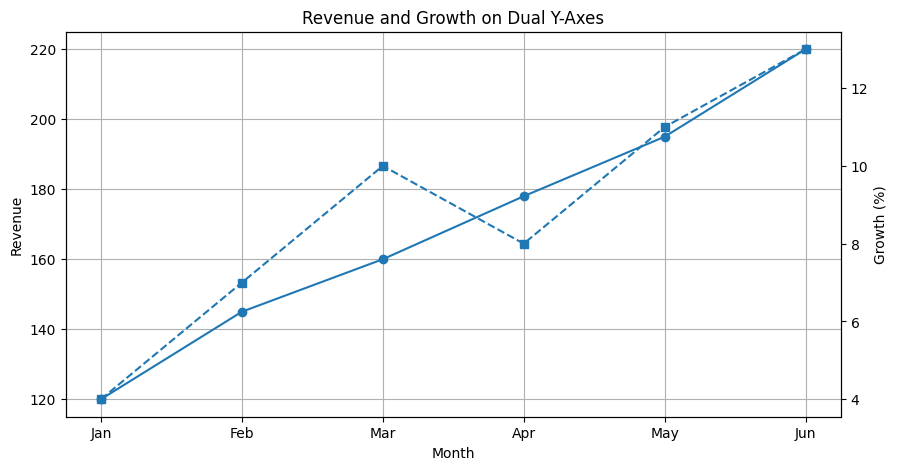

In [49]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
revenue = [120, 145, 160, 178, 195, 220]
growth = [4, 7, 10, 8, 11, 13]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(months, revenue, marker="o", label="Revenue")
ax2.plot(months, growth, marker="s", linestyle="--", label="Growth")

ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue")
ax2.set_ylabel("Growth (%)")
ax1.set_title("Revenue and Growth on Dual Y-Axes")

ax1.grid(True)
plt.show()

# Module 24 — `twiny()` and Secondary X-Axes

`twiny()` creates a second x-axis sharing the same y-axis.

It is useful when two horizontal coordinate systems describe the same vertical observations.

Use it only when the relationship between the two x-scales is meaningful and clearly explained.

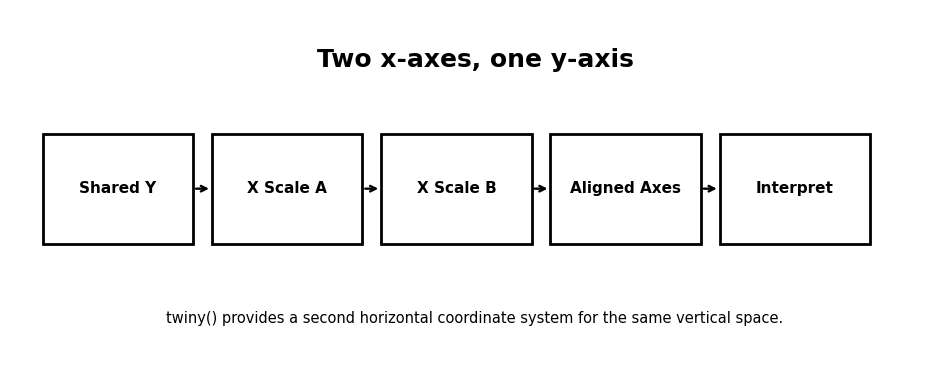

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Shared Y', 'X Scale A', 'X Scale B', 'Aligned Axes', 'Interpret']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Two x-axes, one y-axis', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'twiny() provides a second horizontal coordinate system for the same vertical space.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

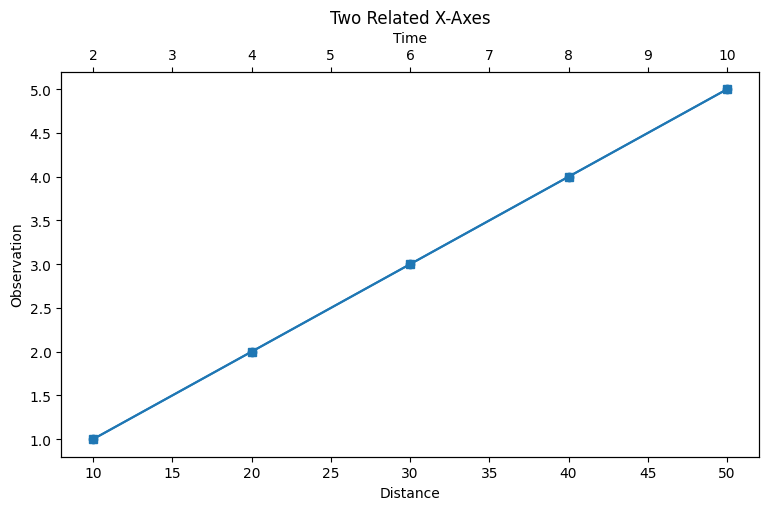

In [51]:
y = np.array([1, 2, 3, 4, 5])
distance = np.array([10, 20, 30, 40, 50])
time = distance / 5

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twiny()

ax1.plot(distance, y, marker="o")
ax2.plot(time, y, marker="s")

ax1.set_xlabel("Distance")
ax2.set_xlabel("Time")
ax1.set_ylabel("Observation")
ax1.set_title("Two Related X-Axes")

plt.show()

# Module 25 — Professional Styles with `plt.style.use()`

Matplotlib includes style sheets that change many visual defaults at once.

Examples include:

```python
plt.style.use("default")
plt.style.use("classic")
plt.style.use("ggplot")
```

A style sheet can help maintain consistency across a project.

For teaching and reproducibility, it is useful to know which style is active.

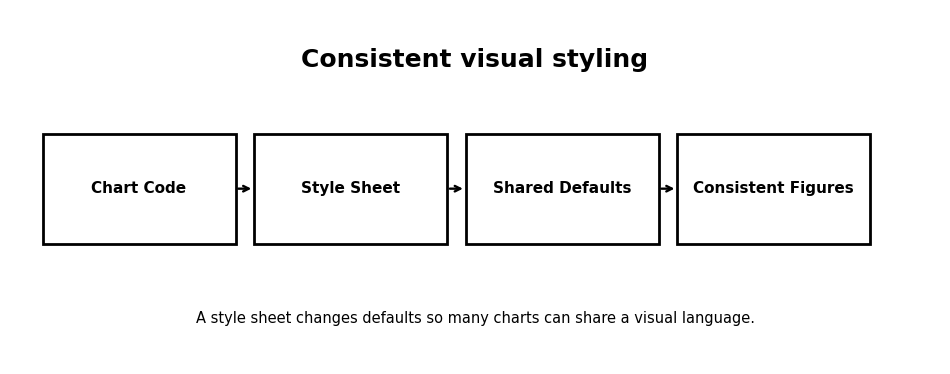

In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Chart Code', 'Style Sheet', 'Shared Defaults', 'Consistent Figures']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Consistent visual styling', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'A style sheet changes defaults so many charts can share a visual language.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

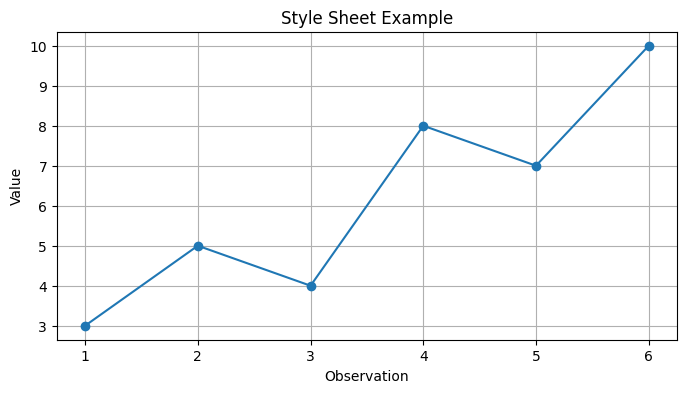

In [53]:
plt.style.use("default")

x = np.arange(1, 7)
y = [3, 5, 4, 8, 7, 10]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, marker="o")
ax.set_title("Style Sheet Example")
ax.set_xlabel("Observation")
ax.set_ylabel("Value")
ax.grid(True)
plt.show()

# Module 26 — `rcParams` for Global Customization

`rcParams` stores Matplotlib's configurable defaults.

This allows a project to establish consistent:

- font sizes
- figure sizes
- line widths
- axes settings
- save settings

A professional workflow should avoid changing global settings accidentally. When experimentation is complete, settings can be reset.

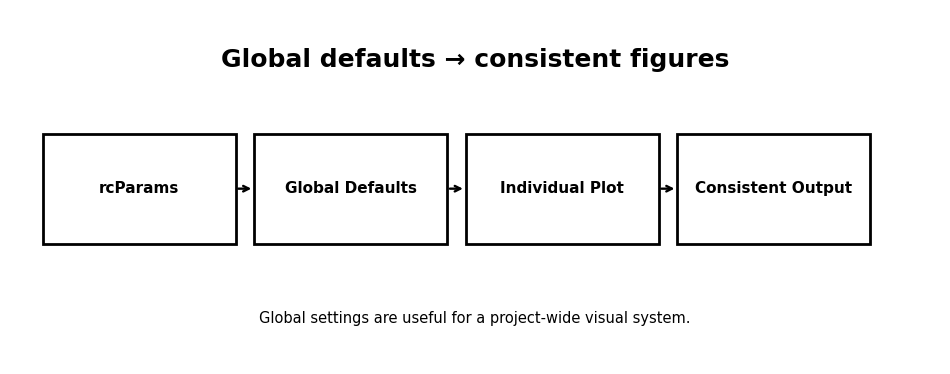

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['rcParams', 'Global Defaults', 'Individual Plot', 'Consistent Output']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Global defaults → consistent figures', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Global settings are useful for a project-wide visual system.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

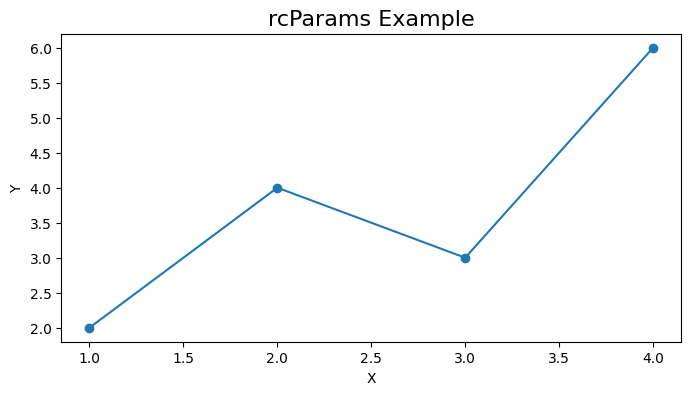

Matplotlib defaults restored.


In [55]:
old_title_size = plt.rcParams["axes.titlesize"]

plt.rcParams["axes.titlesize"] = 16
plt.rcParams["figure.figsize"] = (8, 4)

fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [2, 4, 3, 6], marker="o")
ax.set_title("rcParams Example")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

plt.rcdefaults()
print("Matplotlib defaults restored.")

# Module 27 — Logarithmic Scales

Some datasets span several orders of magnitude.

Linear scales can make small values difficult to see.

Matplotlib provides:

```python
ax.set_yscale("log")
ax.set_xscale("log")
```

Log scales are common in growth curves, scientific data, finance, and heavily skewed measurements.

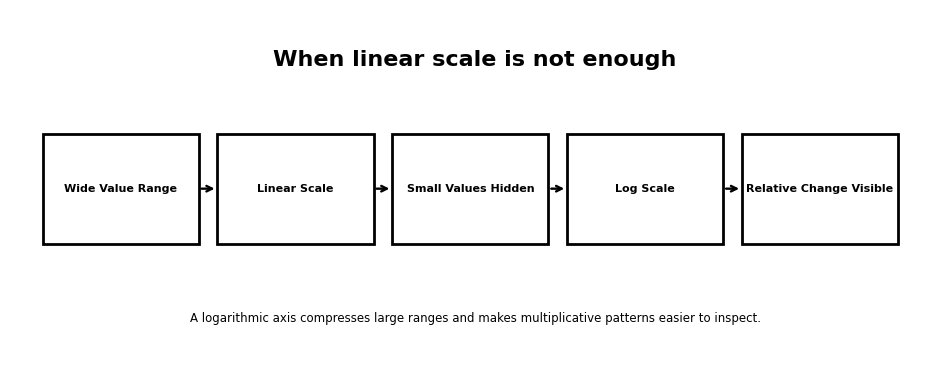

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Wide Value Range', 'Linear Scale', 'Small Values Hidden', 'Log Scale', 'Relative Change Visible']
n = len(steps)
left = 0.035
box_w = 0.94 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=8, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'When linear scale is not enough', ha="center", va="center",
        fontsize=16, fontweight="bold")
ax.text(0.5, 0.13, 'A logarithmic axis compresses large ranges and makes multiplicative patterns easier to inspect.', ha="center", va="center",
        fontsize=8.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

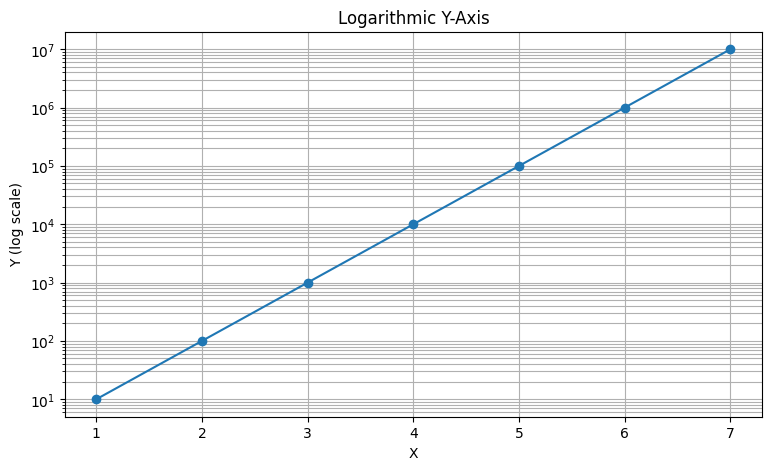

In [57]:
x = np.arange(1, 8)
y = 10 ** x

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y, marker="o")
ax.set_yscale("log")
ax.set_title("Logarithmic Y-Axis")
ax.set_xlabel("X")
ax.set_ylabel("Y (log scale)")
ax.grid(True, which="both")
plt.show()

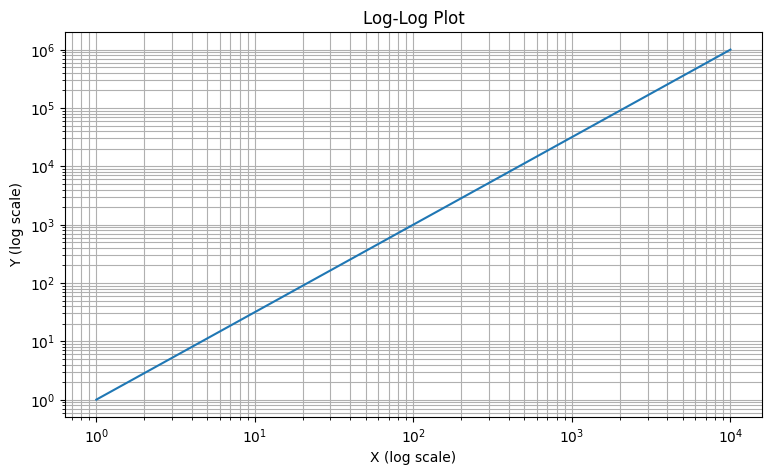

In [58]:
x = np.logspace(0, 4, 200)
y = x ** 1.5

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Log-Log Plot")
ax.set_xlabel("X (log scale)")
ax.set_ylabel("Y (log scale)")
ax.grid(True, which="both")
plt.show()

# Module 28 — `GridSpec` for Advanced Layouts

`GridSpec` allows more flexible subplot arrangements than a simple rectangular `subplots()` call.

For example, one large chart can occupy the top while several smaller charts occupy the bottom.

This is useful for dashboard-style analytical figures.

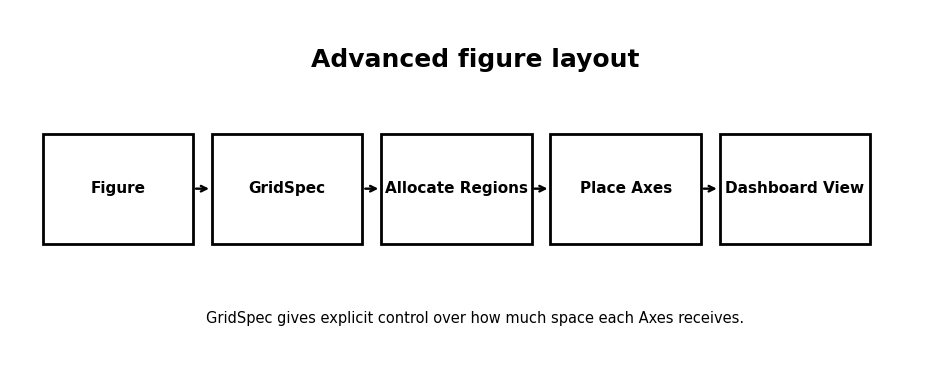

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Figure', 'GridSpec', 'Allocate Regions', 'Place Axes', 'Dashboard View']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Advanced figure layout', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'GridSpec gives explicit control over how much space each Axes receives.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

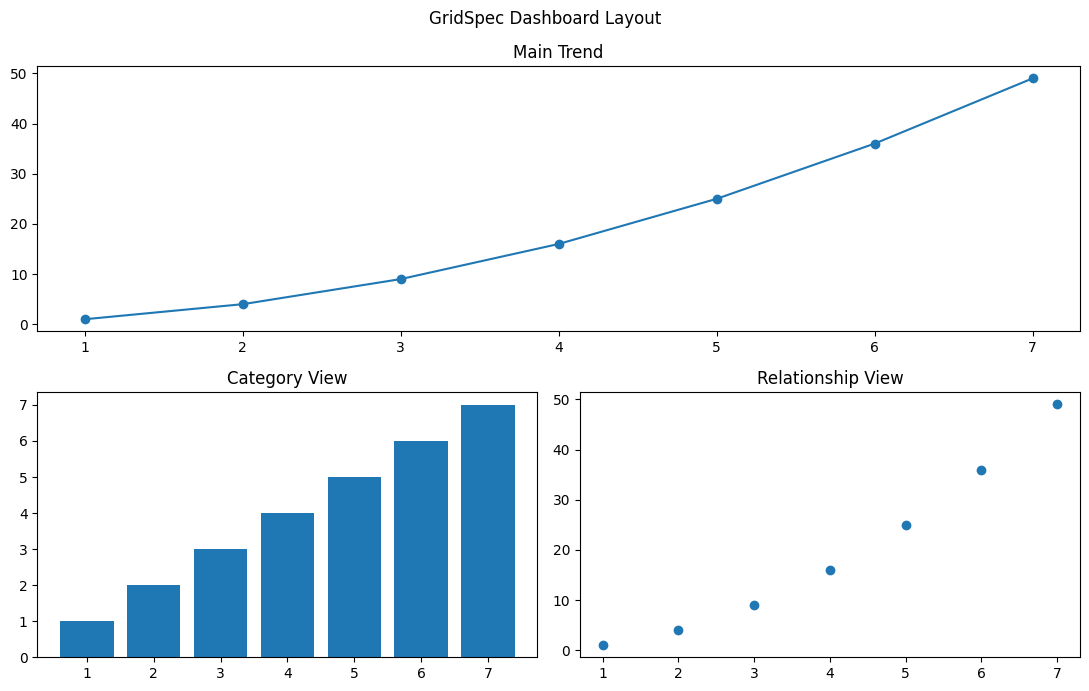

In [60]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(11, 7))
gs = GridSpec(2, 2, figure=fig)

ax_main = fig.add_subplot(gs[0, :])
ax_left = fig.add_subplot(gs[1, 0])
ax_right = fig.add_subplot(gs[1, 1])

x = np.arange(1, 8)

ax_main.plot(x, x**2, marker="o")
ax_main.set_title("Main Trend")

ax_left.bar(x, x)
ax_left.set_title("Category View")

ax_right.scatter(x, x**2)
ax_right.set_title("Relationship View")

fig.suptitle("GridSpec Dashboard Layout")
plt.tight_layout()
plt.show()

# Module 29 — Inset Axes and Zoomed Views

Sometimes a small region of a plot deserves a closer look.

An inset Axes can show a zoomed portion while the main chart preserves the overall context.

This is useful for scientific measurements, financial charts, and time-series events.

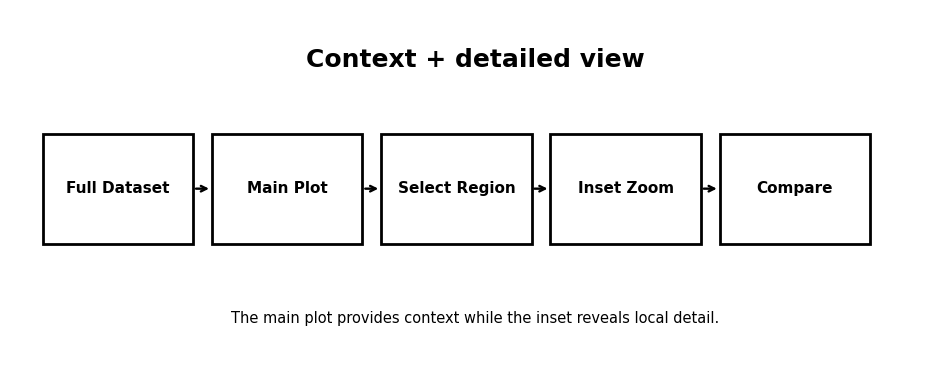

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Full Dataset', 'Main Plot', 'Select Region', 'Inset Zoom', 'Compare']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Context + detailed view', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'The main plot provides context while the inset reveals local detail.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

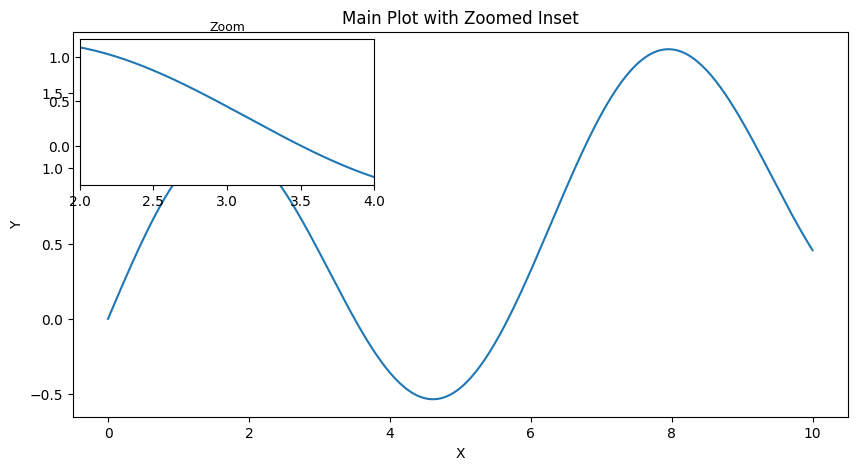

In [62]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

x = np.linspace(0, 10, 300)
y = np.sin(x) + 0.1 * x

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y)
ax.set_title("Main Plot with Zoomed Inset")
ax.set_xlabel("X")
ax.set_ylabel("Y")

inset = inset_axes(ax, width="38%", height="38%", loc="upper left")
inset.plot(x, y)
inset.set_xlim(2, 4)
inset.set_ylim(np.min(y[(x > 2) & (x < 4)]) - 0.1,
               np.max(y[(x > 2) & (x < 4)]) + 0.1)
inset.set_title("Zoom", fontsize=9)

plt.show()

# Module 30 — Date and Time-Series Visualization

Dates are ordered observations with meaningful spacing.

Pandas provides convenient date ranges, while Matplotlib renders the resulting time series.

Common examples include:

- daily temperature
- monthly revenue
- sensor measurements
- sports performance over a season

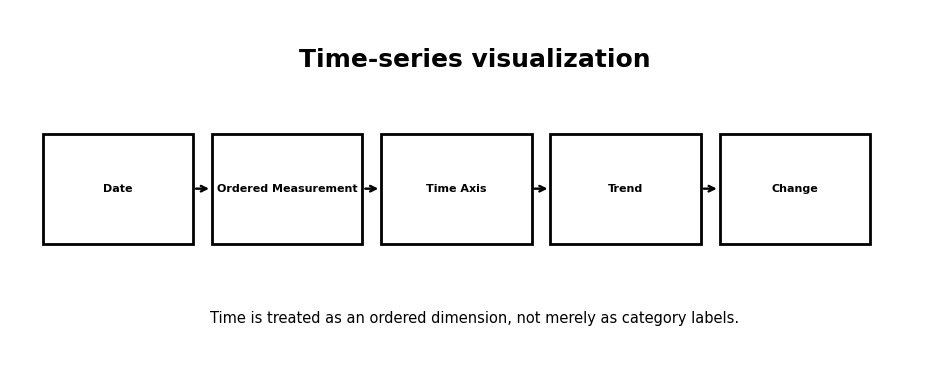

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Date', 'Ordered Measurement', 'Time Axis', 'Trend', 'Change']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=8, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Time-series visualization', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Time is treated as an ordered dimension, not merely as category labels.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

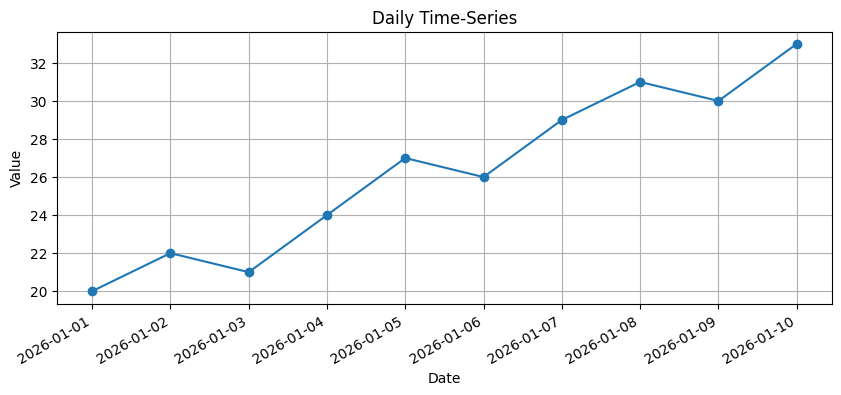

In [64]:
dates = pd.date_range("2026-01-01", periods=10, freq="D")
values = [20, 22, 21, 24, 27, 26, 29, 31, 30, 33]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dates, values, marker="o")
ax.set_title("Daily Time-Series")
ax.set_xlabel("Date")
ax.set_ylabel("Value")
ax.grid(True)
fig.autofmt_xdate()
plt.show()

# Module 31 — 3D Plotting with `mplot3d`

Matplotlib can create 3D visualizations.

The 3D toolkit is useful for:

- mathematical surfaces
- spatial coordinates
- demonstrations
- certain scientific visualizations

However, 3D plots can be harder to read than 2D plots, so they should be used only when the third dimension adds meaningful information.

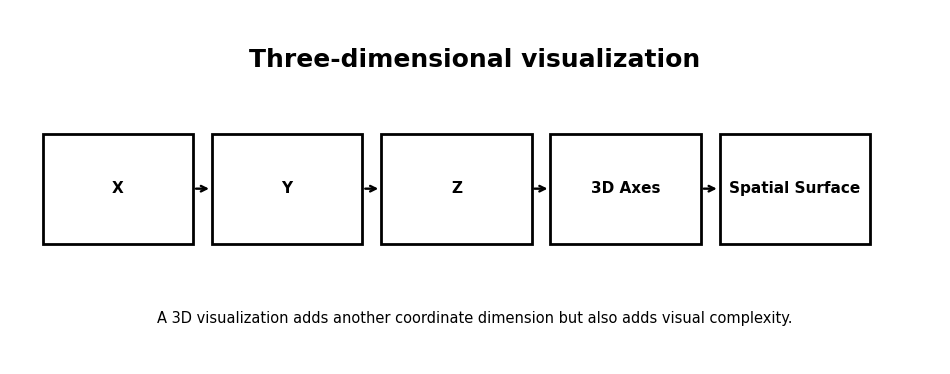

In [65]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['X', 'Y', 'Z', '3D Axes', 'Spatial Surface']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Three-dimensional visualization', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'A 3D visualization adds another coordinate dimension but also adds visual complexity.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

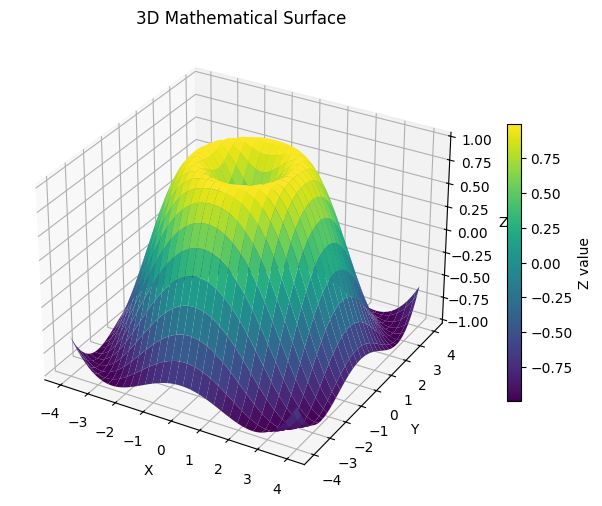

In [66]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

x = np.linspace(-4, 4, 60)
y = np.linspace(-4, 4, 60)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(X, Y, Z, cmap="viridis")

ax.set_title("3D Mathematical Surface")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

fig.colorbar(surface, ax=ax, shrink=0.6, label="Z value")
plt.show()

# Module 32 — Specialized Plots: Stem, Hexbin, and Contour

Matplotlib contains many specialized visualization tools.

### Stem plot
Useful for discrete sequences.

### Hexbin
Useful for large scatter datasets where points overlap heavily.

### Contour
Useful for displaying levels of a continuous surface.

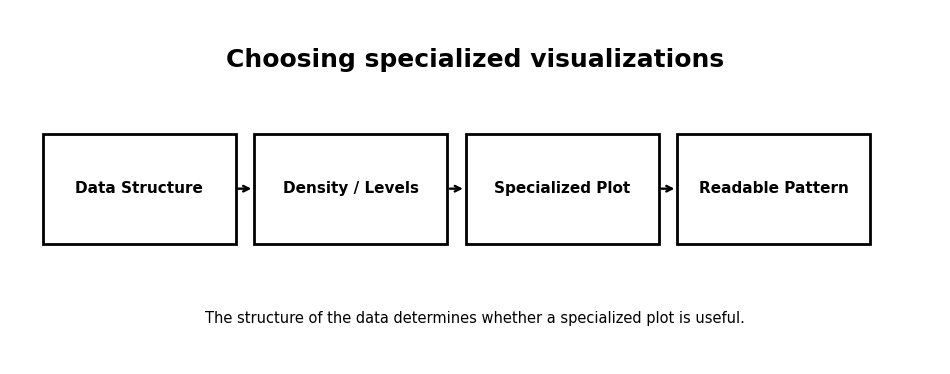

In [67]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Data Structure', 'Density / Levels', 'Specialized Plot', 'Readable Pattern']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Choosing specialized visualizations', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'The structure of the data determines whether a specialized plot is useful.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

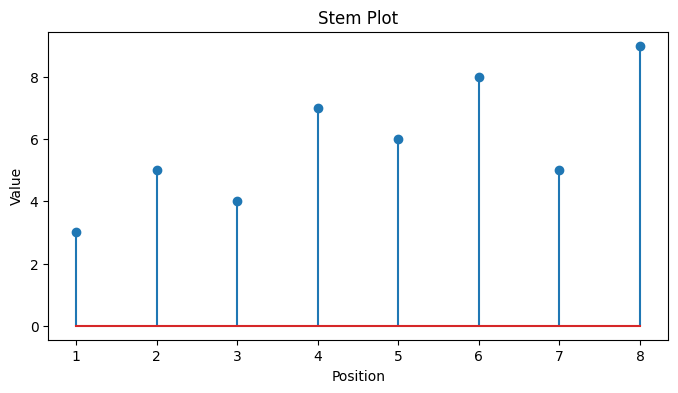

In [68]:
x = np.arange(1, 9)
y = [3, 5, 4, 7, 6, 8, 5, 9]

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(x, y)
ax.set_title("Stem Plot")
ax.set_xlabel("Position")
ax.set_ylabel("Value")
plt.show()

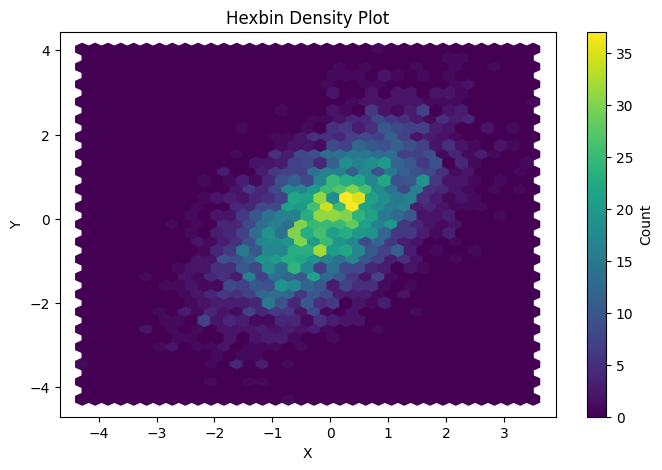

In [69]:
rng = np.random.default_rng(21)
x = rng.normal(size=4000)
y = 0.7 * x + rng.normal(size=4000)

fig, ax = plt.subplots(figsize=(8, 5))
hb = ax.hexbin(x, y, gridsize=35, cmap="viridis")
fig.colorbar(hb, ax=ax, label="Count")
ax.set_title("Hexbin Density Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

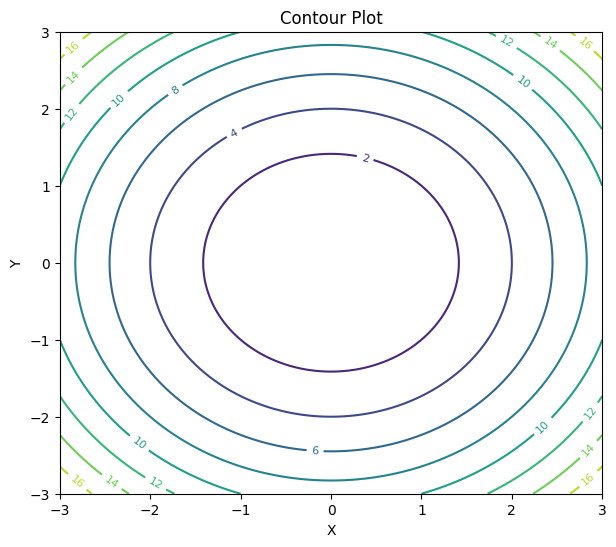

In [70]:
x = np.linspace(-3, 3, 120)
y = np.linspace(-3, 3, 120)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig, ax = plt.subplots(figsize=(7, 6))
contours = ax.contour(X, Y, Z, levels=10)
ax.clabel(contours, inline=True, fontsize=8)
ax.set_title("Contour Plot")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

# Module 33 — Polar Plots

Polar coordinates are useful when angle and radius are meaningful.

Applications can include:

- directional measurements
- cyclic phenomena
- radar-like displays
- periodic patterns

The chart type should match the structure of the data.

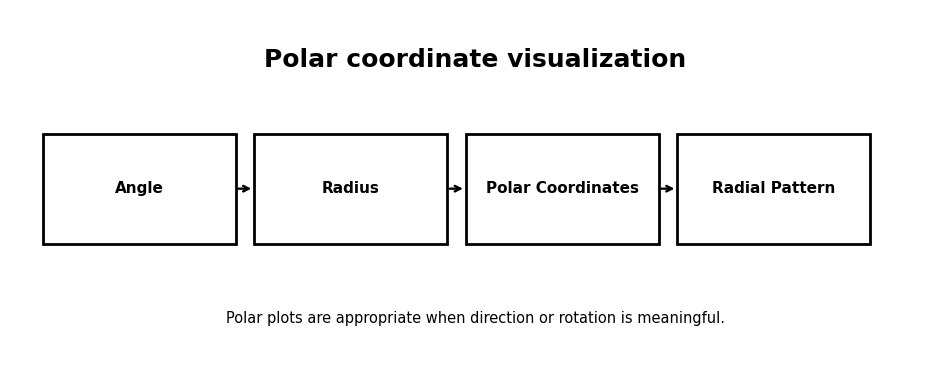

In [71]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Angle', 'Radius', 'Polar Coordinates', 'Radial Pattern']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Polar coordinate visualization', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Polar plots are appropriate when direction or rotation is meaningful.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

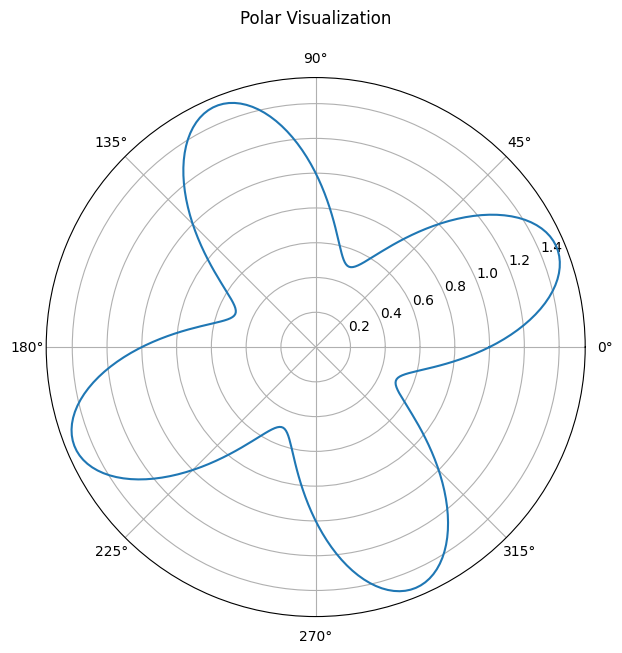

In [72]:
theta = np.linspace(0, 2*np.pi, 300)
radius = 1 + 0.5*np.sin(4*theta)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
ax.plot(theta, radius)
ax.set_title("Polar Visualization", pad=20)
plt.show()

# Module 34 — Text, Shapes, and Patches

Matplotlib is not limited to plotting numerical series.

It can also draw:

- text
- rectangles
- circles
- lines
- arrows
- custom patches

These features are useful for diagrams, annotated analytical figures, and spatial visualizations.

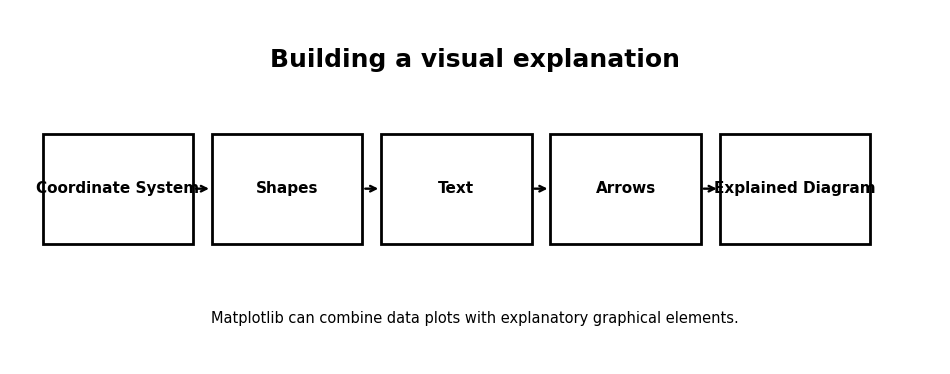

In [73]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Coordinate System', 'Shapes', 'Text', 'Arrows', 'Explained Diagram']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Building a visual explanation', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Matplotlib can combine data plots with explanatory graphical elements.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

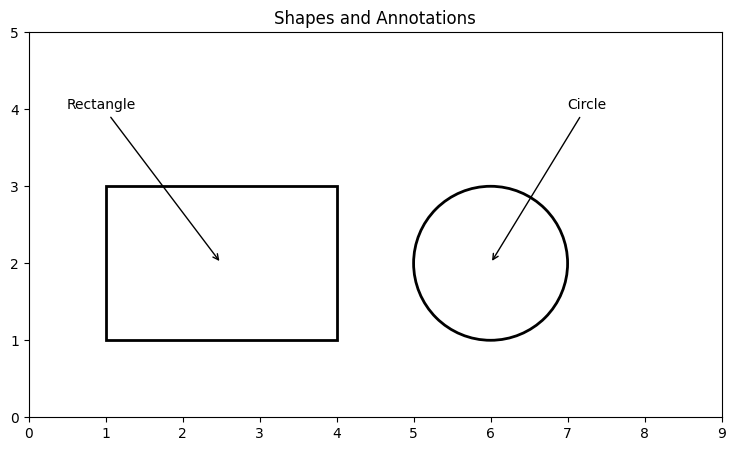

In [74]:
from matplotlib.patches import Rectangle, Circle

fig, ax = plt.subplots(figsize=(9, 5))

ax.add_patch(Rectangle((1, 1), 3, 2, fill=False, linewidth=2))
ax.add_patch(Circle((6, 2), 1, fill=False, linewidth=2))

ax.annotate("Rectangle", xy=(2.5, 2), xytext=(0.5, 4),
            arrowprops={"arrowstyle": "->"})
ax.annotate("Circle", xy=(6, 2), xytext=(7, 4),
            arrowprops={"arrowstyle": "->"})

ax.set_xlim(0, 9)
ax.set_ylim(0, 5)
ax.set_aspect("equal")
ax.set_title("Shapes and Annotations")
plt.show()

# Module 35 — Layout, Figure Size, DPI, and Export

A visualization may look correct inside a notebook but become poorly formatted when exported.

Important concepts:

- `figsize`
- DPI
- `tight_layout()`
- `bbox_inches="tight"`
- PNG for general raster output
- PDF/SVG for scalable vector graphics

Always inspect the saved file.

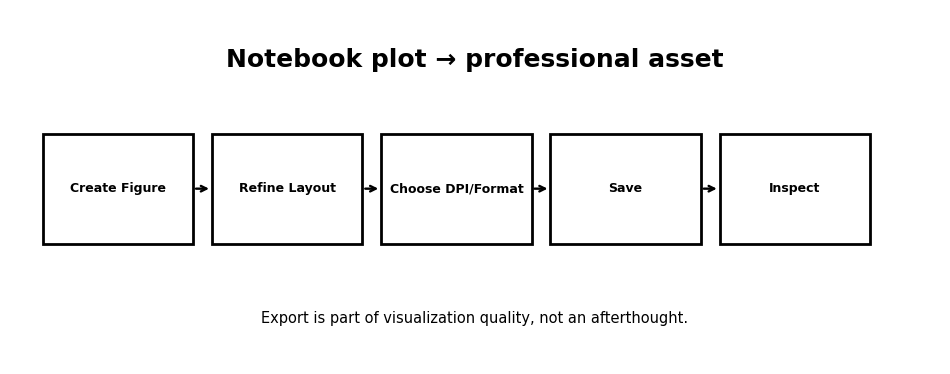

In [47]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Create Figure', 'Refine Layout', 'Choose DPI/Format', 'Save', 'Inspect']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Notebook plot → professional asset', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Export is part of visualization quality, not an afterthought.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

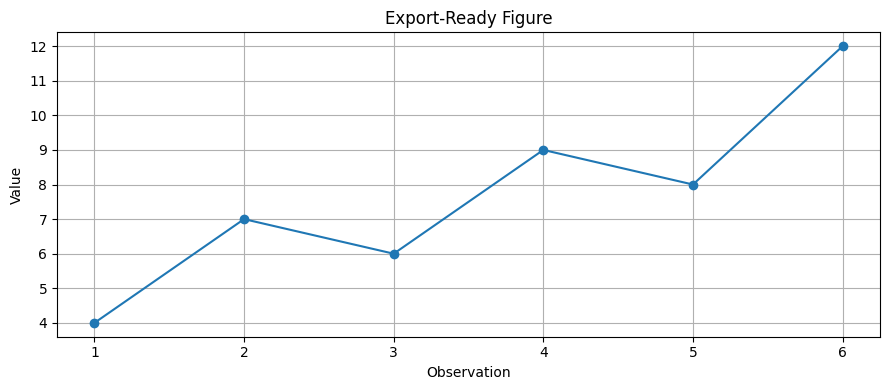

Saved PNG and PDF successfully.


In [76]:
x = np.arange(1, 7)
y = [4, 7, 6, 9, 8, 12]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, y, marker="o")
ax.set_title("Export-Ready Figure")
ax.set_xlabel("Observation")
ax.set_ylabel("Value")
ax.grid(True)

fig.tight_layout()
fig.savefig("matplotlib_export_example.png", dpi=180, bbox_inches="tight")
fig.savefig("matplotlib_export_example.pdf", bbox_inches="tight")

plt.show()
print("Saved PNG and PDF successfully.")

# Module 36 — Debugging Matplotlib

Debugging is not only about fixing syntax errors. A chart can execute successfully and still be wrong or misleading.

Common problems:

- x and y have different lengths
- wrong column selected
- categorical labels in the wrong order
- inappropriate axis scale
- hidden data because of limits
- overlapping labels
- incorrect interpretation of uncertainty
- unreadable legends

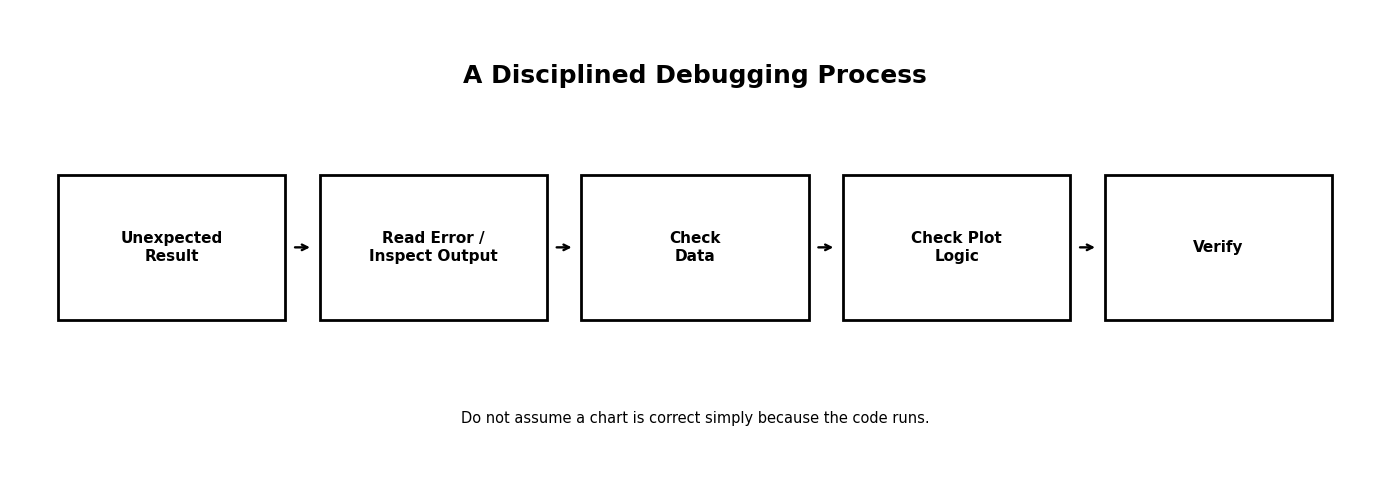

In [54]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 5))

steps = [
    "Unexpected\nResult",
    "Read Error /\nInspect Output",
    "Check\nData",
    "Check Plot\nLogic",
    "Verify"
]

n = len(steps)

# Layout
left = 0.035
right = 0.965
gap = 0.025

total_width = right - left
box_w = (total_width - gap * (n - 1)) / n

box_y = 0.34
box_h = 0.31

# Draw boxes and arrows
for i, label in enumerate(steps):

    x = left + i * (box_w + gap)

    # Box
    ax.add_patch(
        Rectangle(
            (x, box_y),
            box_w,
            box_h,
            fill=False,
            linewidth=2
        )
    )

    # Text
    ax.text(
        x + box_w / 2,
        box_y + box_h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        linespacing=1.3
    )

    # Arrow
    if i < n - 1:
        ax.annotate(
            "",
            xy=(x + box_w + gap - 0.005, box_y + box_h / 2),
            xytext=(x + box_w + 0.005, box_y + box_h / 2),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.7
            }
        )

# Title
ax.text(
    0.5,
    0.86,
    "A Disciplined Debugging Process",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# Explanation
ax.text(
    0.5,
    0.13,
    "Do not assume a chart is correct simply because the code runs.",
    ha="center",
    va="center",
    fontsize=10.5
)

# Clean canvas
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout()
plt.show()

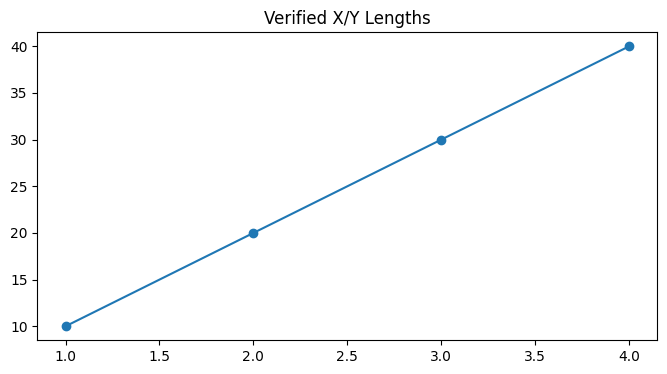

In [78]:
# Correct x/y pairing
x = np.array([1, 2, 3, 4])
y = np.array([10, 20, 30, 40])

assert len(x) == len(y), "X and Y must have the same number of observations."

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, marker="o")
ax.set_title("Verified X/Y Lengths")
plt.show()

# Module 37 — Choosing the Right Visualization

Start with the **question**, not the chart.

| Analytical question | Strong starting point |
|---|---|
| How does a value change over time? | Line |
| Which category is larger? | Bar |
| Do two variables relate? | Scatter |
| How are values distributed? | Histogram |
| How do distributions compare? | Box / Violin |
| How do parts form a whole? | Pie / Stacked area |
| What is the value across a grid? | Heatmap / pcolormesh |
| How uncertain is an estimate? | Errorbar / band |
| Does data span huge ranges? | Log scale |
| Are there spatial coordinates? | Scatter / contour / 3D |

The best chart is the one that communicates the answer clearly.

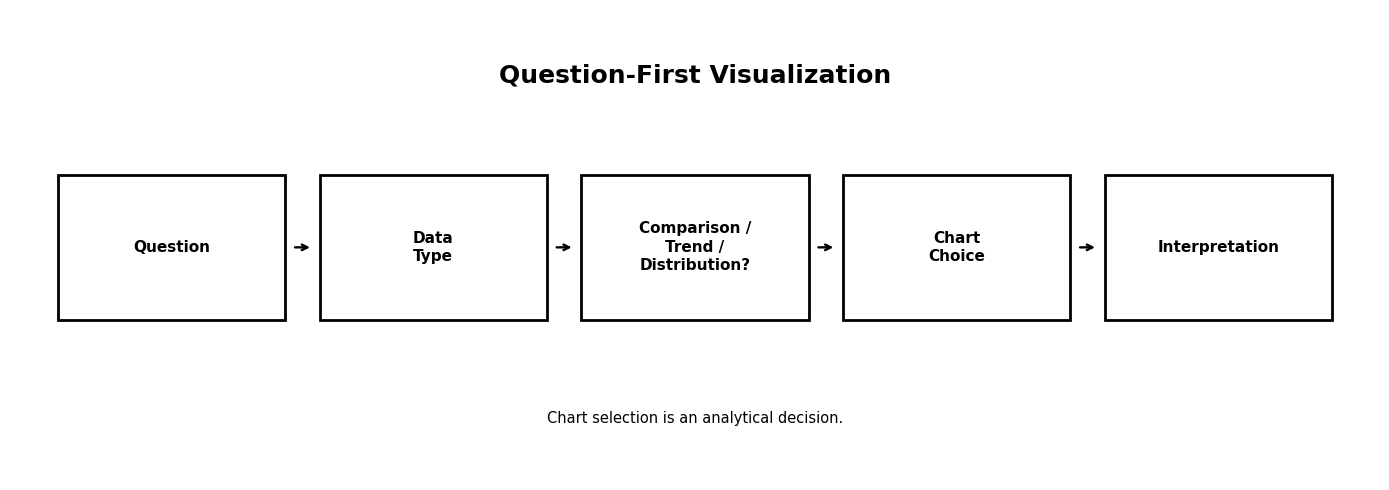

In [55]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 5))

steps = [
    "Question",
    "Data\nType",
    "Comparison /\nTrend /\nDistribution?",
    "Chart\nChoice",
    "Interpretation"
]

n = len(steps)

# Layout
left = 0.035
right = 0.965
gap = 0.025

total_width = right - left
box_w = (total_width - gap * (n - 1)) / n

box_y = 0.34
box_h = 0.31

# Draw boxes and arrows
for i, label in enumerate(steps):

    x = left + i * (box_w + gap)

    # Draw box
    ax.add_patch(
        Rectangle(
            (x, box_y),
            box_w,
            box_h,
            fill=False,
            linewidth=2
        )
    )

    # Text inside box
    ax.text(
        x + box_w / 2,
        box_y + box_h / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        linespacing=1.3
    )

    # Arrow between boxes
    if i < n - 1:

        ax.annotate(
            "",
            xy=(x + box_w + gap - 0.005, box_y + box_h / 2),
            xytext=(x + box_w + 0.005, box_y + box_h / 2),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.7
            }
        )

# Title
ax.text(
    0.5,
    0.86,
    "Question-First Visualization",
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold"
)

# Supporting explanation
ax.text(
    0.5,
    0.13,
    "Chart selection is an analytical decision.",
    ha="center",
    va="center",
    fontsize=10.5
)

# Clean canvas
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout()
plt.show()

In [80]:
questions = [
    ("Trend over time", "Line chart"),
    ("Compare categories", "Bar chart"),
    ("Relationship between variables", "Scatter plot"),
    ("Distribution", "Histogram"),
    ("Uncertainty", "Error bars or confidence band"),
    ("Matrix values", "Heatmap")
]

for question, chart in questions:
    print(f"{question:35} -> {chart}")

Trend over time                     -> Line chart
Compare categories                  -> Bar chart
Relationship between variables      -> Scatter plot
Distribution                        -> Histogram
Uncertainty                         -> Error bars or confidence band
Matrix values                       -> Heatmap


# Module 38 — Football Analytics ⚽

We now connect Matplotlib with a topic that can make visualization more engaging: football.

This is an **educational analytics exercise**, not a professional scouting model.

We will analyze synthetic match data and ask questions such as:

- How did goals change across matches?
- Do more shots correspond to more goals in this sample?
- How does possession compare with goals?
- How can shot locations be represented spatially?

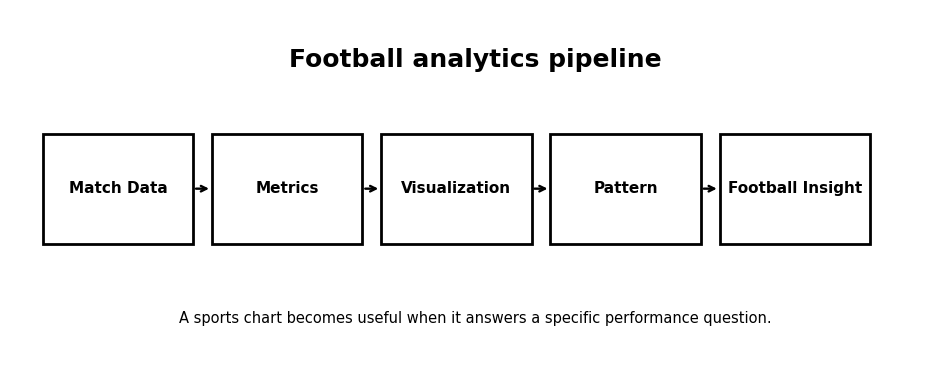

In [81]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Match Data', 'Metrics', 'Visualization', 'Pattern', 'Football Insight']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Football analytics pipeline', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'A sports chart becomes useful when it answers a specific performance question.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

In [82]:
football = pd.DataFrame({
    "Match": ["M1", "M2", "M3", "M4", "M5", "M6", "M7", "M8"],
    "Goals": [2, 1, 3, 0, 2, 2, 1, 4],
    "Shots": [12, 9, 16, 7, 14, 11, 10, 18],
    "Possession": [54, 48, 61, 45, 57, 52, 50, 64],
    "PassAccuracy": [84, 79, 88, 76, 82, 85, 80, 90]
})

display(football)

,Match,Goals,Shots,Possession,PassAccuracy
0,M1,2,12,54,84
1,M2,1,9,48,79
2,M3,3,16,61,88
3,M4,0,7,45,76
4,M5,2,14,57,82
5,M6,2,11,52,85
6,M7,1,10,50,80
7,M8,4,18,64,90


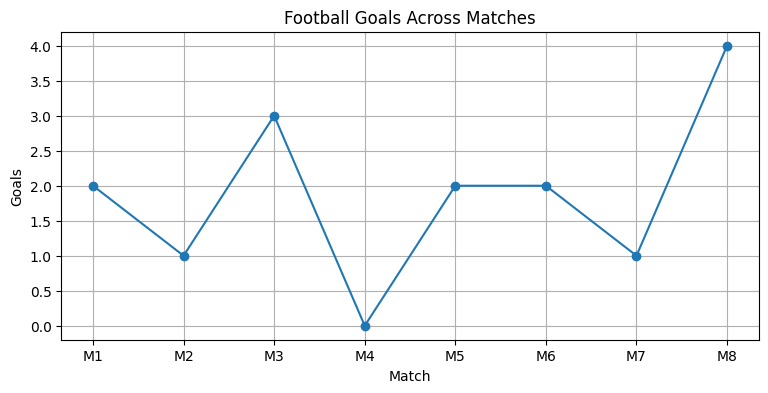

In [83]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(football["Match"], football["Goals"], marker="o")
ax.set_title("Football Goals Across Matches")
ax.set_xlabel("Match")
ax.set_ylabel("Goals")
ax.grid(True)
plt.show()

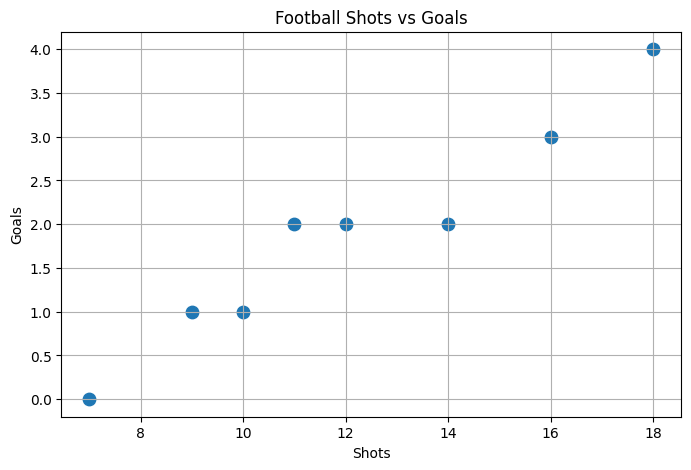

In [84]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(football["Shots"], football["Goals"], s=80)
ax.set_title("Football Shots vs Goals")
ax.set_xlabel("Shots")
ax.set_ylabel("Goals")
ax.grid(True)
plt.show()

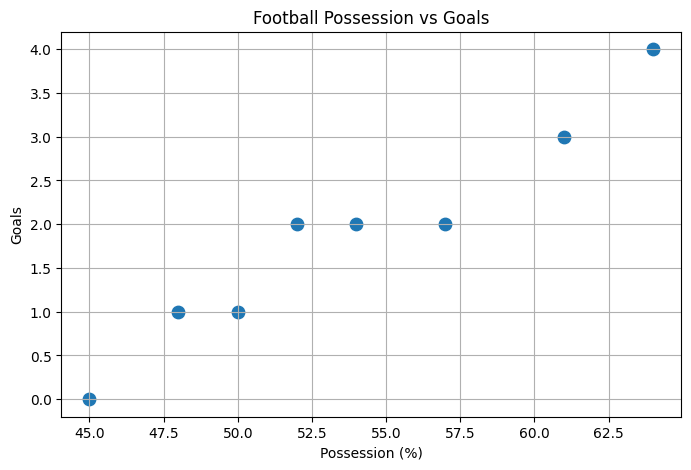

In [85]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(football["Possession"], football["Goals"], s=80)
ax.set_title("Football Possession vs Goals")
ax.set_xlabel("Possession (%)")
ax.set_ylabel("Goals")
ax.grid(True)
plt.show()

## Football Spatial Visualization — Shot Locations

Spatial analytics can represent where events occur on a simplified pitch.

The coordinates below are synthetic.

- horizontal coordinate = pitch width
- vertical coordinate = pitch length
- each point = one shot event

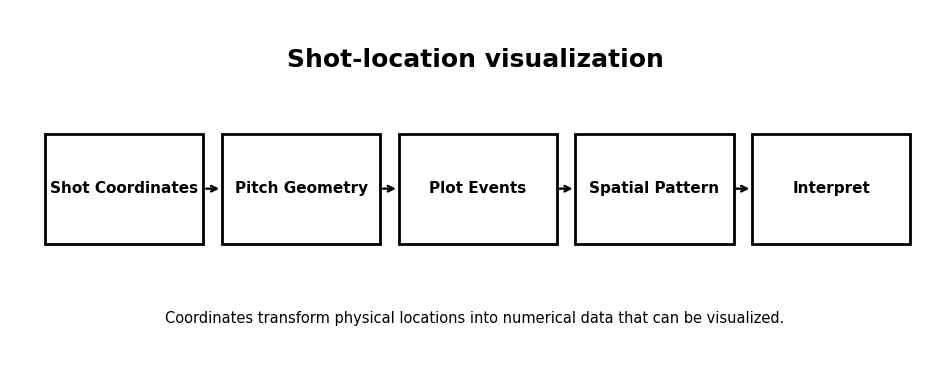

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Shot Coordinates', 'Pitch Geometry', 'Plot Events', 'Spatial Pattern', 'Interpret']
n = len(steps)
left = 0.038
box_w = 0.95/ n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Shot-location visualization', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Coordinates transform physical locations into numerical data that can be visualized.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

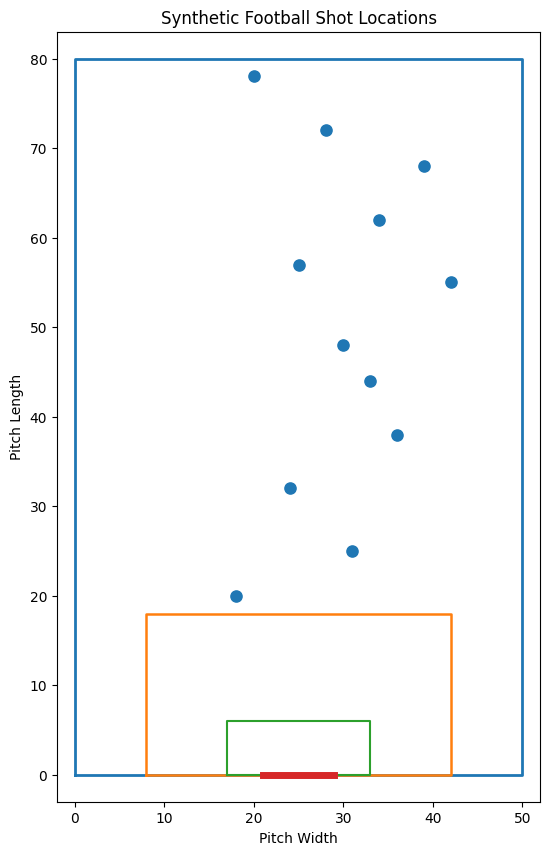

In [87]:
shot_x = [18, 24, 30, 34, 28, 36, 42, 20, 31, 39, 25, 33]
shot_y = [20, 32, 48, 62, 72, 38, 55, 78, 25, 68, 57, 44]

fig, ax = plt.subplots(figsize=(8, 10))

ax.plot([0, 50, 50, 0, 0], [0, 0, 80, 80, 0], linewidth=2)
ax.plot([8, 42, 42, 8, 8], [0, 0, 18, 18, 0], linewidth=1.8)
ax.plot([17, 33, 33, 17, 17], [0, 0, 6, 6, 0], linewidth=1.5)
ax.plot([21, 29], [0, 0], linewidth=5)

ax.scatter(shot_x, shot_y, s=65)
ax.set_xlim(-2, 52)
ax.set_ylim(-3, 83)
ax.set_aspect("equal")
ax.set_title("Synthetic Football Shot Locations")
ax.set_xlabel("Pitch Width")
ax.set_ylabel("Pitch Length")
plt.show()

### What the football spatial chart shows

The rectangle is a simplified pitch. The smaller rectangles represent the penalty and goal areas. The points represent synthetic shot events.

The important analytical idea is:

**event + coordinates → spatial pattern**

A professional sports system could extend this idea using real event data, but the visualization principle remains the same.

# Module 39 — Table Tennis Analytics 🏓

Table tennis is another excellent example because performance is sequential and point-by-point.

We will visualize:

- score progression
- rally wins
- serve success
- synthetic ball locations

Again, all values are educational synthetic data.

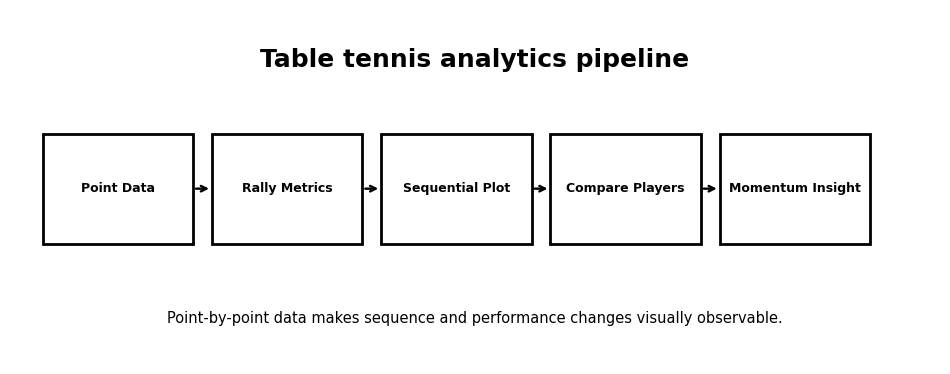

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Point Data', 'Rally Metrics', 'Sequential Plot', 'Compare Players', 'Momentum Insight']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Table tennis analytics pipeline', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'Point-by-point data makes sequence and performance changes visually observable.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

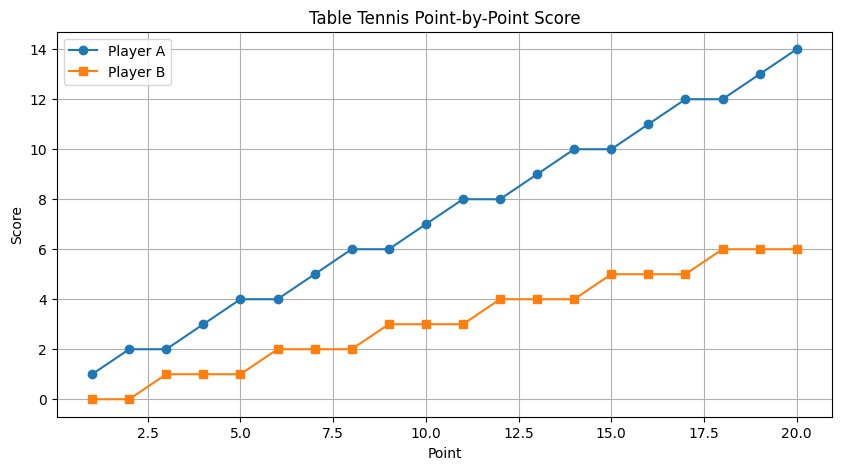

In [89]:
table_tennis = pd.DataFrame({
    "Point": np.arange(1, 21),
    "Player_A_Score": [1,2,2,3,4,4,5,6,6,7,8,8,9,10,10,11,12,12,13,14],
    "Player_B_Score": [0,0,1,1,1,2,2,2,3,3,3,4,4,4,5,5,5,6,6,6]
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(table_tennis["Point"], table_tennis["Player_A_Score"],
        marker="o", label="Player A")
ax.plot(table_tennis["Point"], table_tennis["Player_B_Score"],
        marker="s", label="Player B")
ax.set_title("Table Tennis Point-by-Point Score")
ax.set_xlabel("Point")
ax.set_ylabel("Score")
ax.legend()
ax.grid(True)
plt.show()

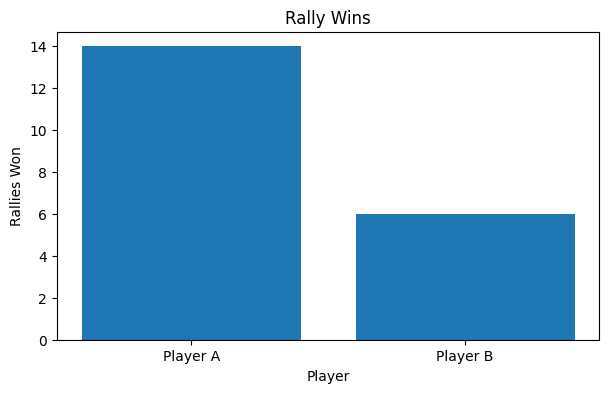

In [90]:
rally_wins = pd.Series({"Player A": 14, "Player B": 6})

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rally_wins.index, rally_wins.values)
ax.set_title("Rally Wins")
ax.set_xlabel("Player")
ax.set_ylabel("Rallies Won")
plt.show()

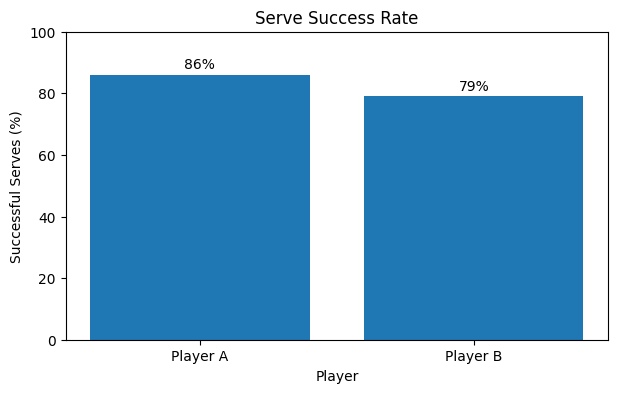

In [91]:
serve_data = pd.DataFrame({
    "Player": ["Player A", "Player B"],
    "SuccessRate": [86, 79]
})

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(serve_data["Player"], serve_data["SuccessRate"])
ax.set_title("Serve Success Rate")
ax.set_xlabel("Player")
ax.set_ylabel("Successful Serves (%)")
ax.set_ylim(0, 100)

for bar, value in zip(bars, serve_data["SuccessRate"]):
    ax.text(bar.get_x() + bar.get_width()/2, value + 2,
            f"{value}%", ha="center")

plt.show()

## Table Tennis Spatial Visualization

A table can be represented using a coordinate system. Each point below is a synthetic ball-location observation.

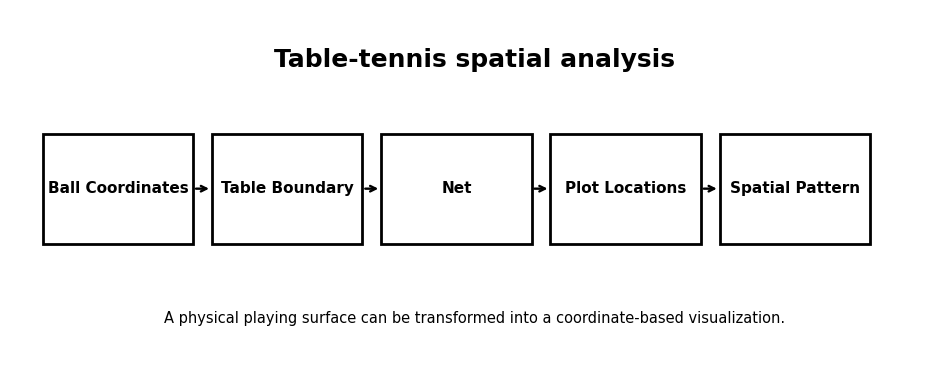

In [92]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Ball Coordinates', 'Table Boundary', 'Net', 'Plot Locations', 'Spatial Pattern']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=11, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Table-tennis spatial analysis', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'A physical playing surface can be transformed into a coordinate-based visualization.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

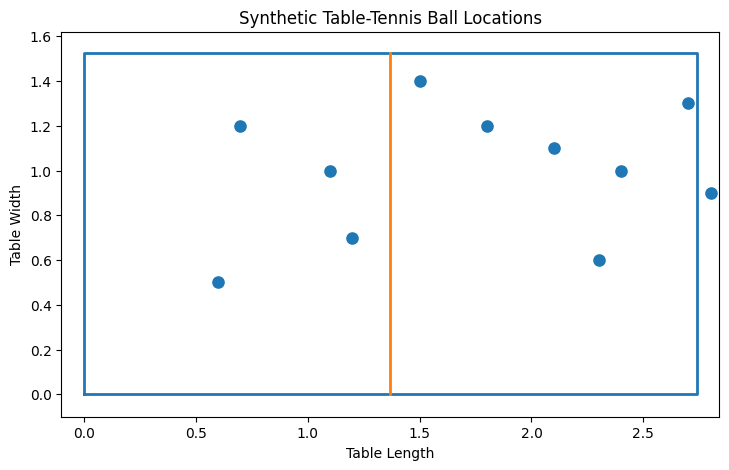

In [93]:
x = [0.6, 1.2, 1.8, 2.4, 2.8, 1.5, 2.1, 0.9, 2.7, 1.1, 2.3, 0.7]
y = [0.5, 0.7, 1.2, 1.0, 0.9, 1.4, 1.1, 1.8, 1.3, 1.0, 0.6, 1.2]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot([0, 2.74, 2.74, 0, 0], [0, 0, 1.525, 1.525, 0], linewidth=2)
ax.plot([1.37, 1.37], [0, 1.525], linewidth=2)
ax.scatter(x, y, s=65)

ax.set_xlim(-0.1, 2.84)
ax.set_ylim(-0.1, 1.62)
ax.set_aspect("equal")
ax.set_title("Synthetic Table-Tennis Ball Locations")
ax.set_xlabel("Table Length")
ax.set_ylabel("Table Width")
plt.show()

# Module 40 — A Complete Mini Visualization Analysis

This final technical module combines several ideas.

We will:

1. create a small dataset
2. inspect it
3. visualize a trend
4. compare categories
5. inspect a relationship
6. add an uncertainty-style band
7. interpret the evidence

The purpose is to practice **analytical thinking**, not simply API memorization.

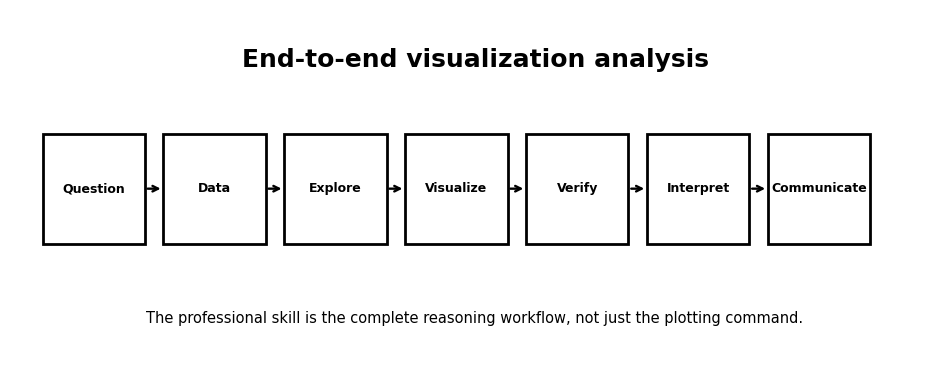

In [64]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Question', 'Data', 'Explore', 'Visualize', 'Verify', 'Interpret', 'Communicate']
n = len(steps)
left = 0.035
box_w = 0.91 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'End-to-end visualization analysis', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'The professional skill is the complete reasoning workflow, not just the plotting command.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

In [95]:
rng = np.random.default_rng(100)

months = np.arange(1, 13)
sales = np.array([120, 128, 125, 140, 152, 160, 158, 171, 180, 176, 190, 205])
variation = np.array([8, 7, 9, 10, 9, 11, 8, 12, 10, 9, 11, 13])

analysis_df = pd.DataFrame({
    "Month": months,
    "Sales": sales,
    "Variation": variation
})

display(analysis_df)

,Month,Sales,Variation
0,1,120,8
1,2,128,7
2,3,125,9
3,4,140,10
4,5,152,9
5,6,160,11
6,7,158,8
7,8,171,12
8,9,180,10
9,10,176,9


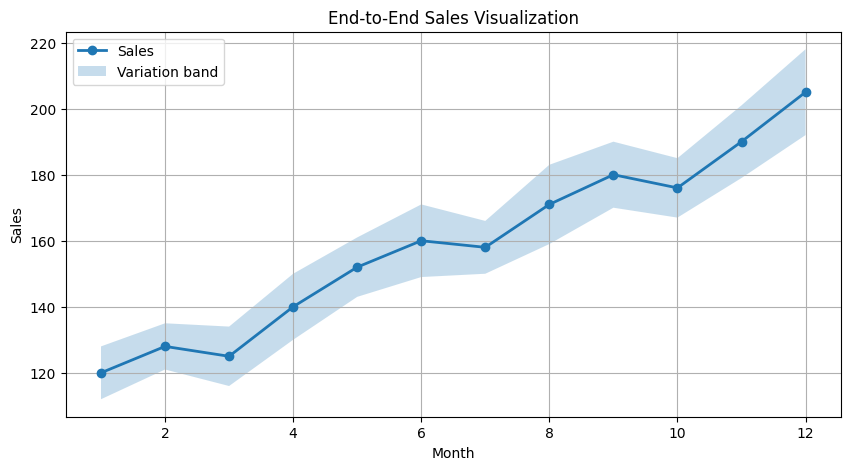

In [96]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(analysis_df["Month"], analysis_df["Sales"],
        marker="o", linewidth=2, label="Sales")

ax.fill_between(
    analysis_df["Month"],
    analysis_df["Sales"] - analysis_df["Variation"],
    analysis_df["Sales"] + analysis_df["Variation"],
    alpha=0.25,
    label="Variation band"
)

ax.set_title("End-to-End Sales Visualization")
ax.set_xlabel("Month")
ax.set_ylabel("Sales")
ax.legend()
ax.grid(True)

plt.show()

### Final interpretation exercise

Before reading an answer from another source, write your own interpretation.

Ask:

- Is the overall trend increasing, decreasing, or mixed?
- Where are the largest values?
- Where is the variation band widest?
- Does the visualization support a simple conclusion?
- What information is still missing?

This habit develops analytical judgment.

# Module 41 — Professional Visualization Quality Checklist

Before calling a visualization complete, inspect it at four levels.

## 1. Data correctness
- Are the values correct?
- Are the variables paired correctly?
- Are units correct?
- Are dates ordered?
- Are missing values handled intentionally?

## 2. Analytical correctness
- Does the chart answer the intended question?
- Is the chosen chart appropriate?
- Is the axis scale appropriate?
- Are uncertainty ranges correctly described?

## 3. Communication quality
- Is the title meaningful?
- Are axes labeled?
- Are units included?
- Is the legend necessary and readable?
- Are labels overlapping?
- Is there unnecessary decoration?

## 4. Reproducibility
- Can another learner run the code?
- Are imports present?
- Are datasets defined?
- Are random examples seeded where useful?
- Can the figure be exported successfully?

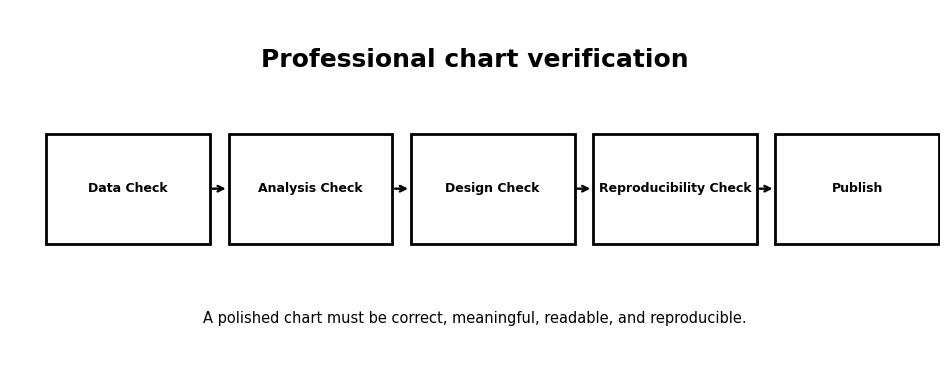

In [69]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4.6))
steps = ['Data Check', 'Analysis Check', 'Design Check', 'Reproducibility Check', 'Publish']
n = len(steps)
left = 0.039
box_w = 0.98 / n
gap = 0.02

for i, label in enumerate(steps):
    x = left + i * box_w
    w = box_w - gap
    ax.add_patch(plt.Rectangle((x, 0.34), w, 0.31,
                               fill=False, linewidth=2))
    ax.text(x + w/2, 0.495, label, ha="center", va="center",
            fontsize=9, fontweight="bold")
    if i < n - 1:
        ax.annotate("", xy=(x + box_w, 0.495),
                    xytext=(x + w, 0.495),
                    arrowprops={"arrowstyle": "->", "linewidth": 1.7})

ax.text(0.5, 0.86, 'Professional chart verification', ha="center", va="center",
        fontsize=18, fontweight="bold")
ax.text(0.5, 0.13, 'A polished chart must be correct, meaningful, readable, and reproducible.', ha="center", va="center",
        fontsize=10.5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")
plt.show()

In [98]:
# A simple reproducibility check
required_columns = {"Month", "Sales", "Variation"}

assert required_columns.issubset(analysis_df.columns)
assert len(analysis_df["Month"]) == len(analysis_df["Sales"])
assert len(analysis_df["Sales"]) == len(analysis_df["Variation"])

print("Data structure verification passed.")

Data structure verification passed.


# 📝 Final Practice — Questions Only

> **Student Notebook Rule:** This section intentionally contains questions only. No answers or solutions are provided here.

## Fundamentals

### 1. First Figure
Create a Figure and Axes and plot five observations.

### 2. Line Chart
Create a line chart for:

```python
days = ["Mon", "Tue", "Wed", "Thu", "Fri"]
sales = [20, 24, 19, 30, 35]
```

Add a title, labels, markers, and grid.

### 3. Bar Chart
Create a bar chart for four subjects and their scores.

### 4. Scatter Plot
Create a scatter plot showing the relationship between study hours and scores.

### 5. Histogram
Generate 300 numerical observations and compare two different bin counts.

## Intermediate Visualization

### 6. Subplots
Create one Figure containing a line chart, bar chart, and scatter plot.

### 7. Annotation
Annotate the maximum point in a line chart.

### 8. Box Plot
Compare the distributions of three groups.

### 9. Violin Plot
Visualize the same three groups using a violin plot.

### 10. Heatmap
Create a 5×5 numerical matrix and display it with `imshow()` and a colorbar.

### 11. Correlation
Create a DataFrame with at least four numerical variables and visualize its correlation matrix.

### 12. `pcolormesh()`
Create a coordinate grid and visualize a continuous mathematical function.

## Advanced Visualization

### 13. `fill_between()`
Create a trend with a lower and upper uncertainty bound.

### 14. `errorbar()`
Plot six measurements with different uncertainty values.

### 15. `stackplot()`
Visualize three components contributing to a total over twelve months.

### 16. `twinx()`
Create one chart containing revenue and growth percentage on separate y-axes.

### 17. `twiny()`
Create two related x-axis scales sharing one y-axis.

### 18. Log Scale
Create a dataset spanning several orders of magnitude and compare linear and logarithmic scales.

### 19. `GridSpec`
Design a dashboard containing one large chart and three smaller charts.

### 20. 3D
Create a mathematical 3D surface using `mplot3d`.

## Sports Analytics

### 21. Football
Create a match dataset containing goals, shots, possession, and passing accuracy.

Produce:
- goals across matches
- shots vs goals
- possession vs goals

Write one analytical sentence for each.

### 22. Football Spatial Analysis
Create synthetic shot coordinates and draw a simplified football pitch.

### 23. Table Tennis
Create point-by-point scores for two players and visualize score progression.

### 24. Table Tennis Performance
Compare rally wins and serve success.

### 25. Table Tennis Spatial Analysis
Create synthetic ball-location coordinates and draw a simplified table.

## Final Challenge

### 26. Complete Visualization Report
Choose a dataset of your own.

Your notebook must include:

- a clear analytical question
- data inspection
- at least three appropriate charts
- one advanced visualization technique
- correct labels and units
- at least one annotation
- a professional layout
- saved output
- a written interpretation
- a short limitations section

Your objective is not to use the largest number of Matplotlib functions.

Your objective is to **communicate useful information correctly and clearly**.

# 🎓 Congratulations — You Have Reached the End of the Free Python Course!

## The Course Is Complete

You have reached the planned end of this free Python course.

The course began with the fundamentals of Python programming and progressed toward numerical computing, data analysis, and data visualization.

The final sequence was:

**Python → NumPy → Pandas → Matplotlib**

You have now learned how to move from raw information to a visual explanation.

---

# 📚 What You Covered

## Python Foundations

You learned the core concepts required to write Python programs, including:

- syntax and structure
- variables
- data types
- operators
- conditions
- loops
- functions
- data structures
- file handling
- errors and exceptions
- problem-solving fundamentals

## NumPy

You progressed into numerical computing through:

- arrays
- indexing and slicing
- array operations
- mathematical functions
- numerical transformations
- efficient numerical workflows

## Pandas

You learned how to work with structured data through:

- Series
- DataFrames
- data inspection
- selection and filtering
- sorting
- missing values
- cleaning
- grouping
- aggregation
- combining data
- exploratory analysis

## Matplotlib

You progressed from basic plots to a broad visualization toolkit:

- Figure and Axes
- line charts
- bar charts
- scatter plots
- histograms
- pie charts
- box plots
- violin plots
- annotations
- ticks and limits
- legends and grids
- subplots
- object-oriented plotting
- NumPy integration
- Pandas integration
- `imshow()`
- heatmaps
- `colorbar()`
- `cmap`
- correlation matrices
- `pcolormesh()`
- `fill_between()`
- `errorbar()`
- `stackplot()`
- `twinx()`
- `twiny()`
- `plt.style.use()`
- `rcParams`
- logarithmic axes
- `GridSpec`
- inset axes
- time-series visualization
- 3D plotting
- stem plots
- hexbin plots
- contour plots
- polar plots
- shapes and patches
- export and DPI
- debugging
- chart selection
- professional visualization principles
- football analytics
- table tennis analytics

---

# 👨‍💻 About This Course

This **free Python course** was designed and developed by **Saad** as a small contribution toward improving access to programming education.

The course was created for students and beginners who want to learn Python but may not have access to paid courses.

The central goal is simple:

> **Make learning Python more accessible, understandable, and approachable for beginners.**

The course was designed around the belief that learning programming should involve more than memorizing syntax.

Students should understand:

- what a concept means
- why it exists
- what the code is doing
- what output should be expected
- how to verify the result
- how to recognize mistakes
- how the concept can be applied

That is why this course uses explanations, executable examples, visual diagrams, analytical charts, practice questions, and real-world-inspired examples.

---

# 🌱 Why This Course Was Created

Access to quality educational material can make a meaningful difference in a student's learning journey.

This course is intended as a small contribution toward that goal.

Instead of keeping the knowledge limited to one learner, the project turns that knowledge into a resource that other beginners can use.

The idea is:

**Learn → Build → Explain → Share → Help Others Learn**

If this course helps even one student understand programming, begin a technical journey, or gain confidence in coding, then the effort behind creating it has value.

---

# ⚽🏓 Why Sports Analytics Was Included

Sports can make technical concepts more intuitive because learners already understand the underlying subject.

Football and table tennis examples demonstrate that Matplotlib is not limited to classroom datasets.

The same visualization principles can be applied to:

- match performance
- scoring trends
- player statistics
- spatial events
- rally sequences
- performance comparisons
- uncertainty
- time-series data

The purpose is to show learners that programming can connect with subjects they genuinely enjoy.

---

# 🎯 What Comes Next?

Finishing a course does not mean finishing your learning.

The next stage is to use these foundations to explore areas such as:

- scientific computing
- machine learning
- data engineering
- artificial intelligence
- engineering analysis
- automation
- research
- software development

The direction depends on the learner.

---

# 🏁 Final Message

Thank you for completing the **Free Python Course**.

You started with the fundamentals and reached the point where you can work with numerical data, structured data, and visualizations.

More importantly, you have practiced a way of thinking:

> **Understand → Predict → Code → Verify → Debug → Apply**

Keep practicing. Keep experimenting. Keep building.

## 🎓 The Free Python Course Ends Here.

## 🚀 Your Learning Does Not.